# Data Loading

In [30]:
import os
import glob

DATA_DIR = 'data'

def get_sit_to_stand_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_1_*.csv')
    
    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_water_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_2_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_step_count_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_3_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]
    


In [31]:
get_sit_to_stand_files()

(['data/ashish_1_yes.csv',
  'data/enas_1_yes.csv',
  'data/ghefar_1_yes.csv',
  'data/nour_1_yes.csv',
  'data/p10_1_yes.csv',
  'data/p4_1_yes.csv',
  'data/p5_1_yes.csv',
  'data/p8_1_yes.csv',
  'data/p9_1_yes.csv',
  'data/xhoel_1_yes.csv'],
 ['data/ashish_1_no.csv',
  'data/enas_1_no.csv',
  'data/ghefar_1_no.csv',
  'data/nour_1_no.csv',
  'data/p10_1_no.csv',
  'data/p4_1_no.csv',
  'data/p5_1_no.csv',
  'data/p8_1_no.csv',
  'data/p9_1_no.csv',
  'data/xhoel_1_no.csv'])

In [32]:
get_water_task_files()

(['data/ashish_2_yes.csv',
  'data/enas_2_yes.csv',
  'data/ghefar_2_yes.csv',
  'data/nour_2_yes.csv',
  'data/p10_2_yes.csv',
  'data/p4_2_yes.csv',
  'data/p5_2_yes.csv',
  'data/p8_2_yes.csv',
  'data/p9_2_yes.csv',
  'data/xhoel_2_yes.csv'],
 ['data/ashish_2_no.csv',
  'data/enas_2_no.csv',
  'data/ghefar_2_no.csv',
  'data/nour_2_no.csv',
  'data/p10_2_no.csv',
  'data/p4_2_no.csv',
  'data/p5_2_no.csv',
  'data/p8_2_no.csv',
  'data/p9_2_no.csv',
  'data/xhoel_2_no.csv'])

In [33]:
get_step_count_task_files()

(['data/ashish_3_yes.csv',
  'data/enas_3_yes.csv',
  'data/ghefar_3_yes.csv',
  'data/nour_3_yes.csv',
  'data/p10_3_yes.csv',
  'data/p4_3_yes.csv',
  'data/p5_3_yes.csv',
  'data/p8_3_yes.csv',
  'data/p9_3_yes.csv',
  'data/xhoel_3_yes.csv'],
 ['data/ashish_3_no.csv',
  'data/enas_3_no.csv',
  'data/ghefar_3_no.csv',
  'data/nour_3_no.csv',
  'data/p10_3_no.csv',
  'data/p4_3_no.csv',
  'data/p5_3_no.csv',
  'data/p8_3_no.csv',
  'data/p9_3_no.csv',
  'data/xhoel_3_no.csv'])

# Data Preprocessing 

In [34]:
# Construct dataframes for each task

import pandas as pd

sit_to_stand_yes, sit_to_stand_no = get_sit_to_stand_files()

dfs_sit_to_stand_yes = [pd.read_csv(f) for f in sit_to_stand_yes]
dfs_sit_to_stand_no = [pd.read_csv(f) for f in sit_to_stand_no]

water_task_yes, water_task_no = get_water_task_files()

dfs_water_task_yes = [pd.read_csv(f) for f in water_task_yes]
dfs_water_task_no = [pd.read_csv(f) for f in water_task_no]

step_count_task_yes, step_count_task_no = get_step_count_task_files()

dfs_step_count_task_yes = [pd.read_csv(f) for f in step_count_task_yes]
dfs_step_count_task_no = [pd.read_csv(f) for f in step_count_task_no]


In [35]:
def preprocess_sit_to_stand_data(df):
    """
    Preprocess the sit to stand data.
    """
    from scipy import signal, integrate
    import numpy as np

    # Convert timestamp_ms to seconds starting from 0
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000

    # Calculate magnitude of acceleration 
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )

    # Apply detrending to each axis
    df['acc_detrended_x'] = signal.detrend(df['freeAcceleration_m/s²_x'], type='linear')
    df['acc_detrended_y'] = signal.detrend(df['freeAcceleration_m/s²_y'], type='linear')
    df['acc_detrended_z'] = signal.detrend(df['freeAcceleration_m/s²_z'], type='linear')

    # Calculate detrended magnitude of acceleration
    df['acceleration_magnitude_detrended'] = np.sqrt(df['acc_detrended_x']**2 + df['acc_detrended_y']**2 + df['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df['velocity_z'] = integrate.cumulative_trapezoid(df['acc_detrended_z'], df['time_s'], initial=0)
    df['velocity_x'] = integrate.cumulative_trapezoid(df['acc_detrended_x'], df['time_s'], initial=0)
    df['velocity_y'] = integrate.cumulative_trapezoid(df['acc_detrended_y'], df['time_s'], initial=0)

    # Calculate magnitude of velocity
    df['velocity_magnitude'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2 + df['velocity_z']**2)

    # Calculate position with detrending
    df['position_z'] = integrate.cumulative_trapezoid(df['velocity_z'], df['time_s'], initial=0)
    df['position_x'] = integrate.cumulative_trapezoid(df['velocity_x'], df['time_s'], initial=0)
    df['position_y'] = integrate.cumulative_trapezoid(df['velocity_y'], df['time_s'], initial=0)

    return df

dfs_sit_to_stand_yes_preprocessed = [preprocess_sit_to_stand_data(df) for df in dfs_sit_to_stand_yes]
dfs_sit_to_stand_no_preprocessed = [preprocess_sit_to_stand_data(df) for df in dfs_sit_to_stand_no]

# Data Exploration and Visualization 

In [36]:
dfs_sit_to_stand_no_preprocessed[0]

,timestamp_ms,timestamp_μs,freeAcceleration_m/s²_x,freeAcceleration_m/s²_y,freeAcceleration_m/s²_z,time_s,acceleration_magnitude,acc_detrended_x,acc_detrended_y,acc_detrended_z,acceleration_magnitude_detrended,velocity_z,velocity_x,velocity_y,velocity_magnitude,position_z,position_x,position_y
0,1746704814859,209719360,0.047203,-0.167005,0.283479,0.000,0.332384,-0.013365,-0.239460,0.163328,0.290165,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1746704814876,209736027,0.038527,-0.128904,0.256366,0.017,0.289524,-0.022086,-0.201454,0.136254,0.244206,0.002546,-0.000301,-0.003748,0.004541,0.000022,-0.000003,-0.000032
2,1746704814892,209752694,0.040116,-0.065615,0.185970,0.033,0.201245,-0.020543,-0.138260,0.065899,0.154533,0.004164,-0.000642,-0.006465,0.007717,0.000075,-0.000010,-0.000114
3,1746704814909,209769361,0.015788,0.011174,0.267086,0.050,0.267786,-0.044915,-0.061567,0.147054,0.165628,0.005974,-0.001199,-0.008164,0.010187,0.000161,-0.000026,-0.000238
4,1746704814926,209786028,0.013383,0.116792,0.386025,0.067,0.403528,-0.047365,0.043955,0.266033,0.273768,0.009485,-0.001983,-0.008314,0.012768,0.000293,-0.000053,-0.000378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1782,1746704844560,239419954,1.038621,-0.952962,-1.862821,29.701,2.336016,0.897970,-1.195588,-1.912185,2.427392,0.001922,-0.072213,0.069659,0.100353,0.016065,0.023060,-0.072925
1783,1746704844576,239436621,1.016820,-0.380841,-0.648541,29.717,1.264740,0.876123,-0.623562,-0.697866,1.281967,-0.018958,-0.058020,0.055105,0.082234,0.015928,0.022018,-0.071927
1784,1746704844593,239453288,1.064942,-0.680544,-0.057891,29.734,1.265145,0.924200,-0.923361,-0.107176,1.310812,-0.025801,-0.042717,0.041957,0.065198,0.015548,0.021162,-0.071102
1785,1746704844610,239469955,1.247072,-0.734097,0.777641,29.751,1.642807,1.106286,-0.977010,0.728396,1.645897,-0.020521,-0.025458,0.025803,0.041654,0.015154,0.020582,-0.070526


In [37]:
def plot_column_sns(df, column_names=[], title=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    sns.set_style('whitegrid')

    color_palatte = 'colorblind'
    sns.set_palette(color_palatte)
    plt.figure(figsize=(16, 6))
    for i, column_name in enumerate(column_names):
        # plot the column_name vs time_s and include appropriate legend
        sns.lineplot(
            data=df,
            x='time_s',
            y=column_name,
            alpha=0.8,
            label=column_name
        )
        plt.tight_layout()
        plt.xticks(np.arange(0.0, 30.5, 2)) 
        plt.yticks(np.arange(-6, 6.5, 1))
    plt.title(title)
    plt.show()

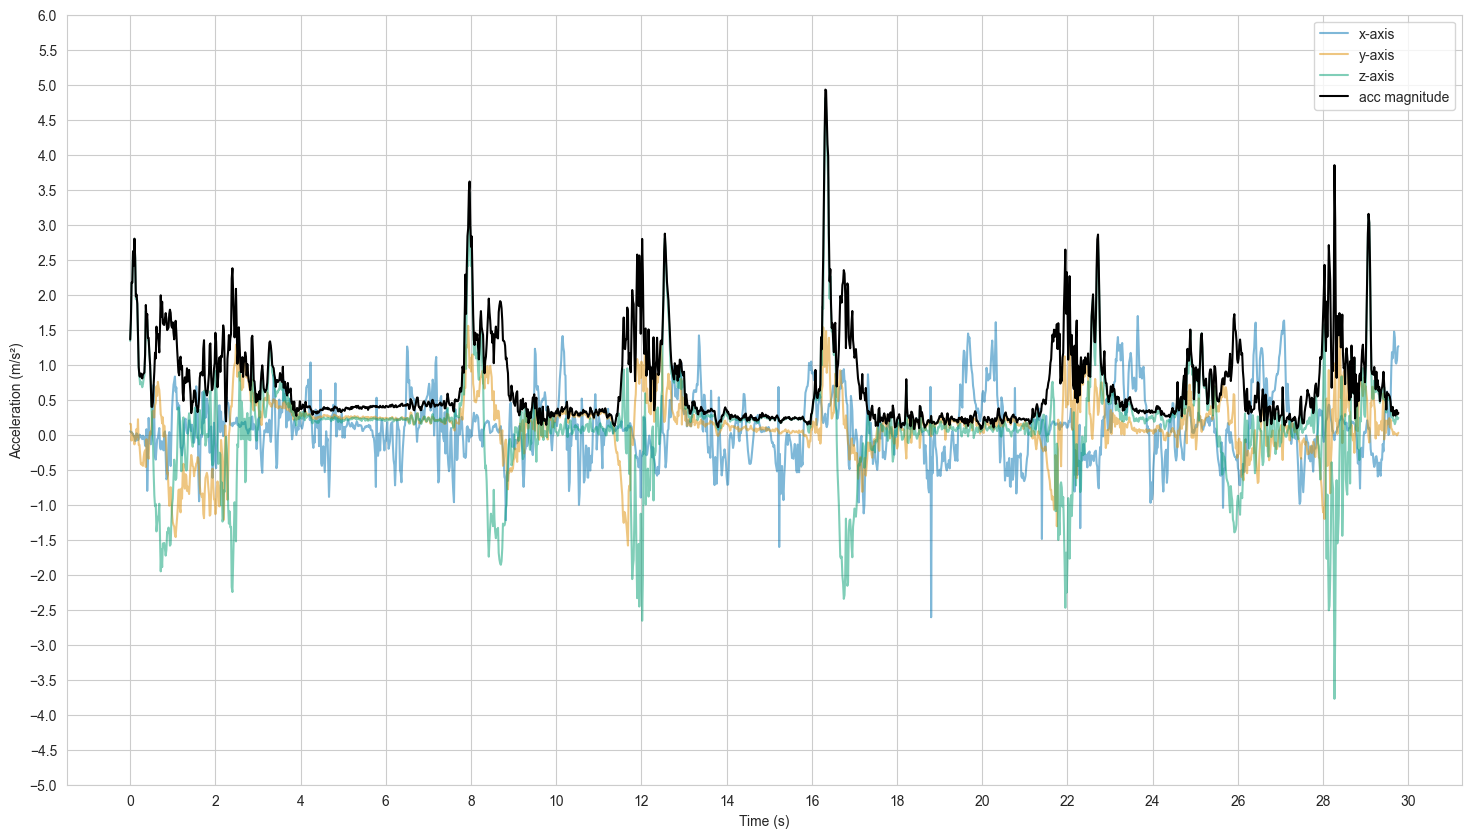

In [49]:
# Plot the acceleration along x, y and z axis for dfs_standard[0]

plt.figure(figsize=(18, 10))
plt.plot(dfs_sit_to_stand_yes_preprocessed[0]['time_s'], dfs_sit_to_stand_no_preprocessed[0]['freeAcceleration_m/s²_x'], label='x-axis', alpha=0.5)
plt.plot(dfs_sit_to_stand_yes_preprocessed[0]['time_s'], dfs_sit_to_stand_yes_preprocessed[0]['freeAcceleration_m/s²_y'], label='y-axis', alpha=0.5)
# plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_y_filtered'], label='y_filtered')
plt.plot(dfs_sit_to_stand_yes_preprocessed[0]['time_s'], dfs_sit_to_stand_yes_preprocessed[0]['freeAcceleration_m/s²_z'], label='z-axis', alpha=0.5)
plt.plot(dfs_sit_to_stand_yes_preprocessed[0]['time_s'], dfs_sit_to_stand_yes_preprocessed[0]['acceleration_magnitude'], label='acc magnitude', color='black',)
plt.yticks(np.arange(-5, 6.5, 0.5))
plt.xticks(np.arange(0, 31.5, 2))
plt.xlabel('Time (s)')  
plt.ylabel('Acceleration (m/s²)')
plt.legend()
# plt.title('Acceleration along x, y and z axis')
plt.show()

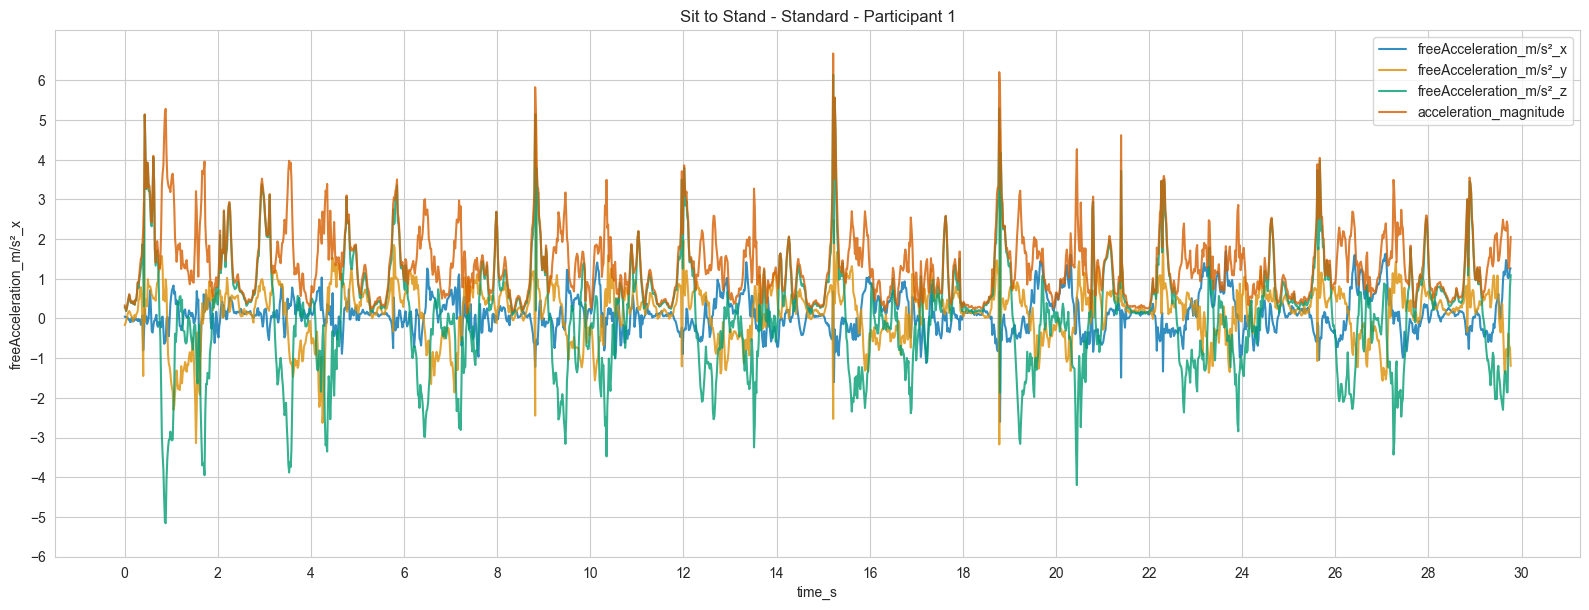

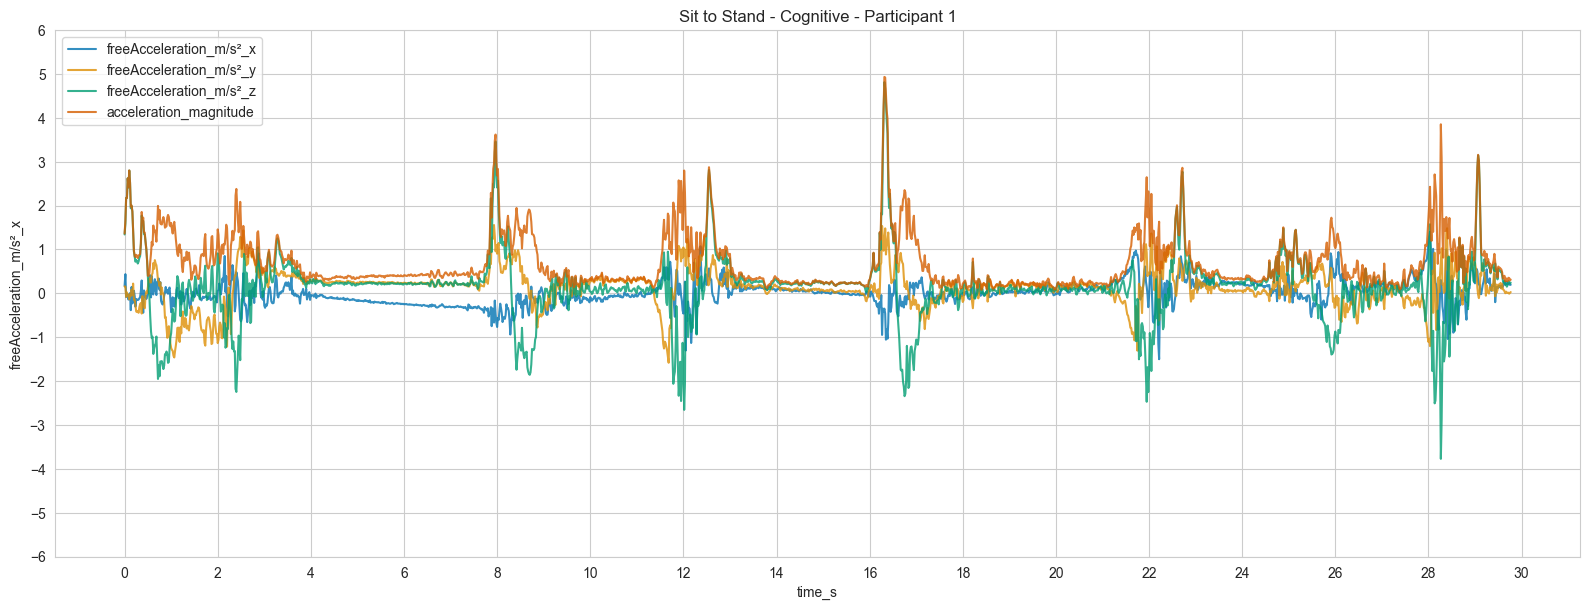

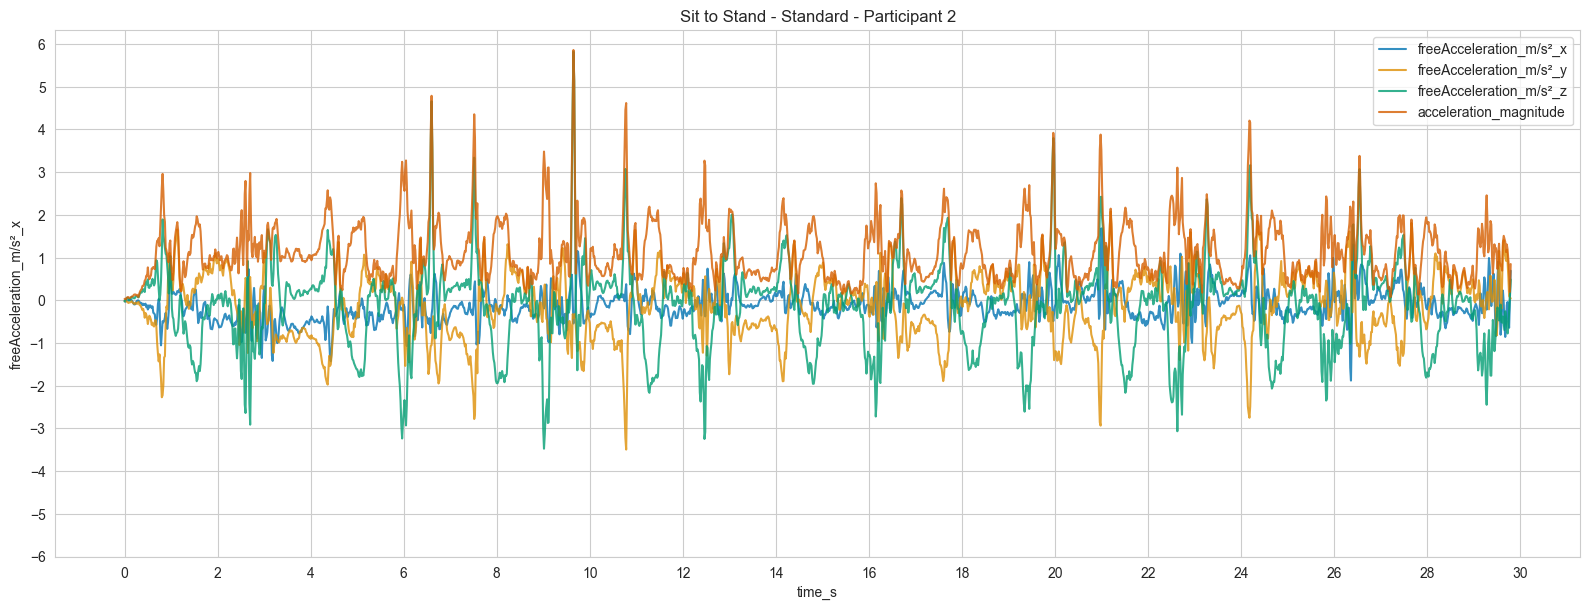

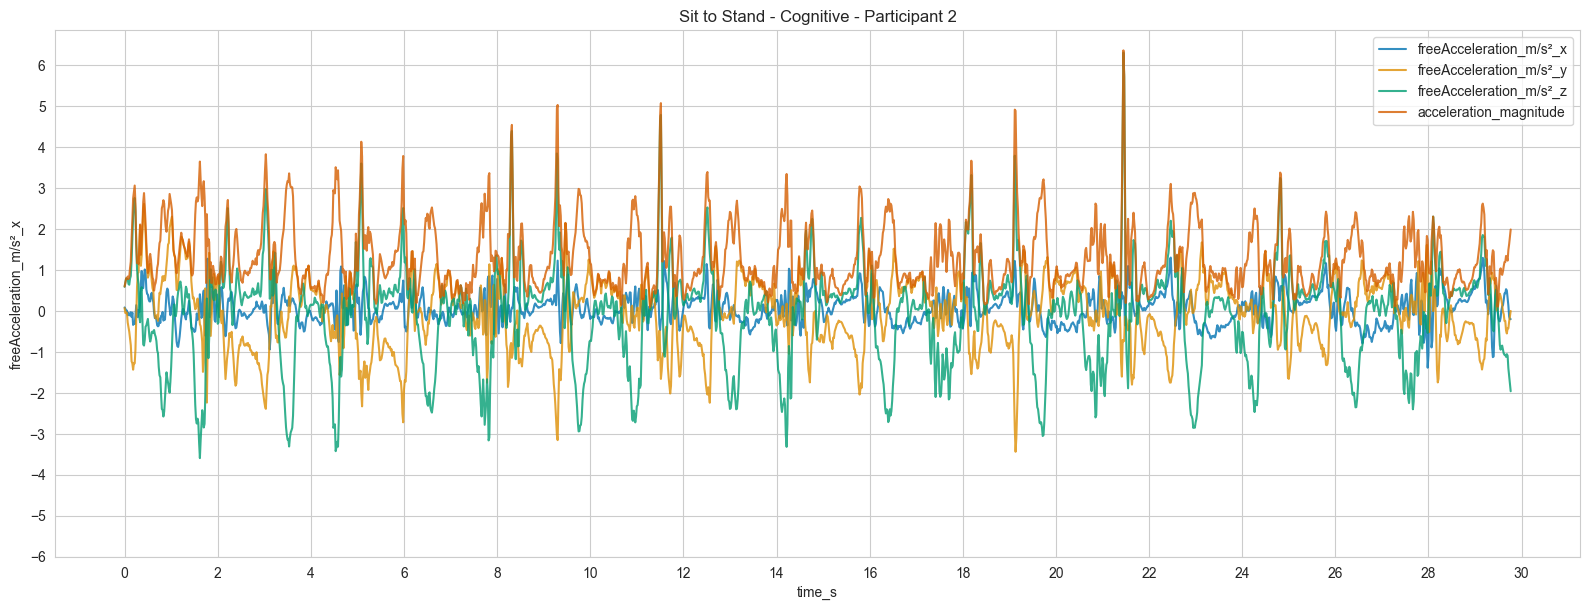

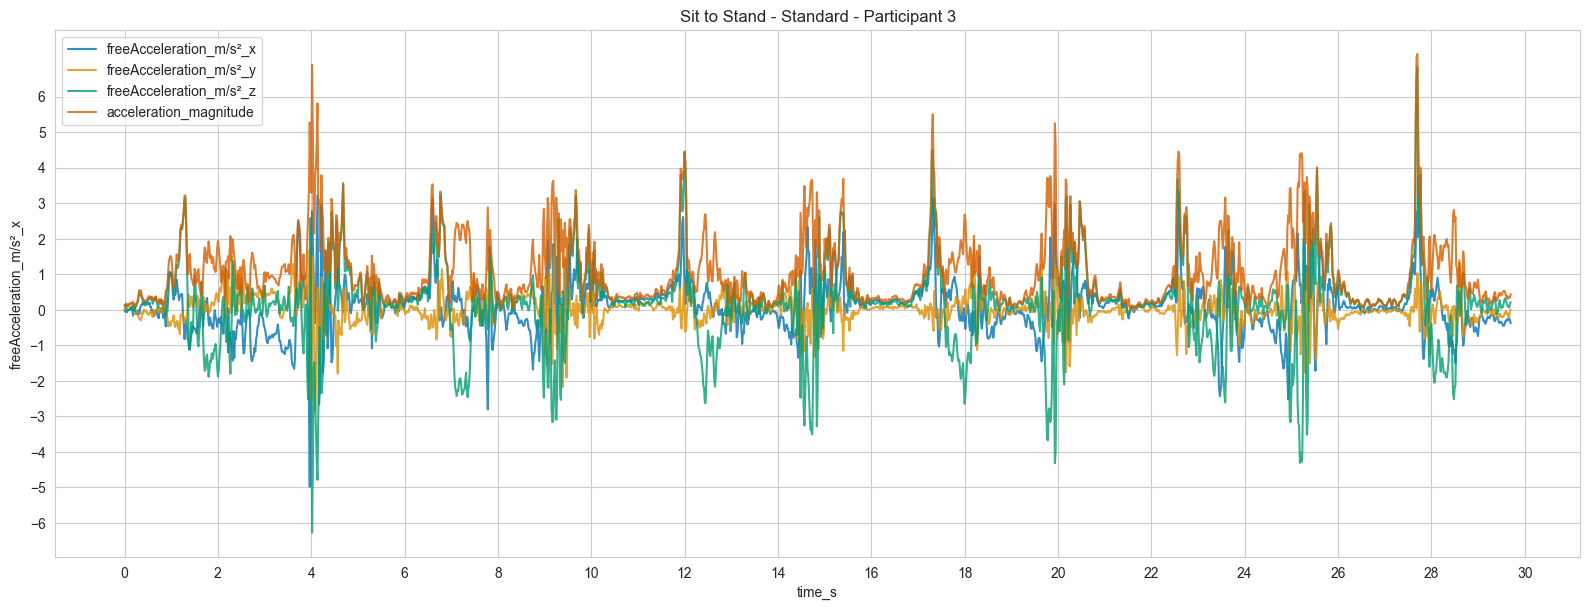

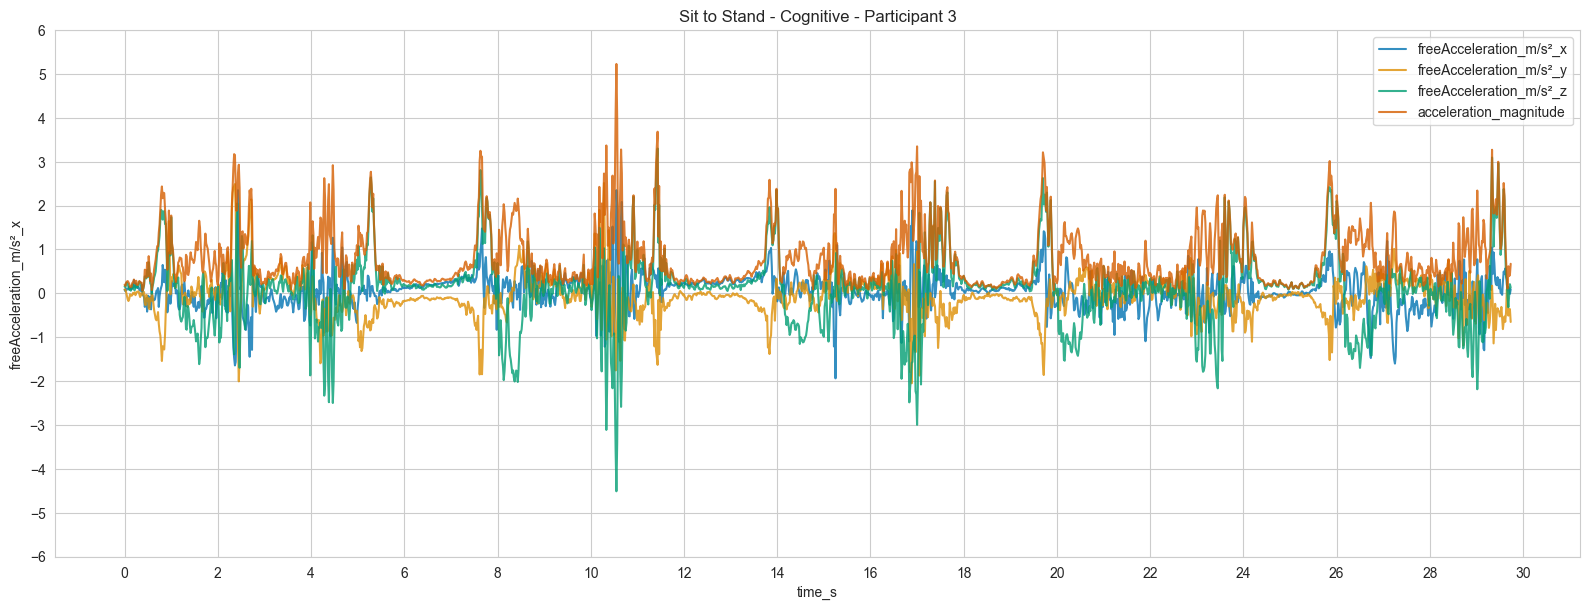

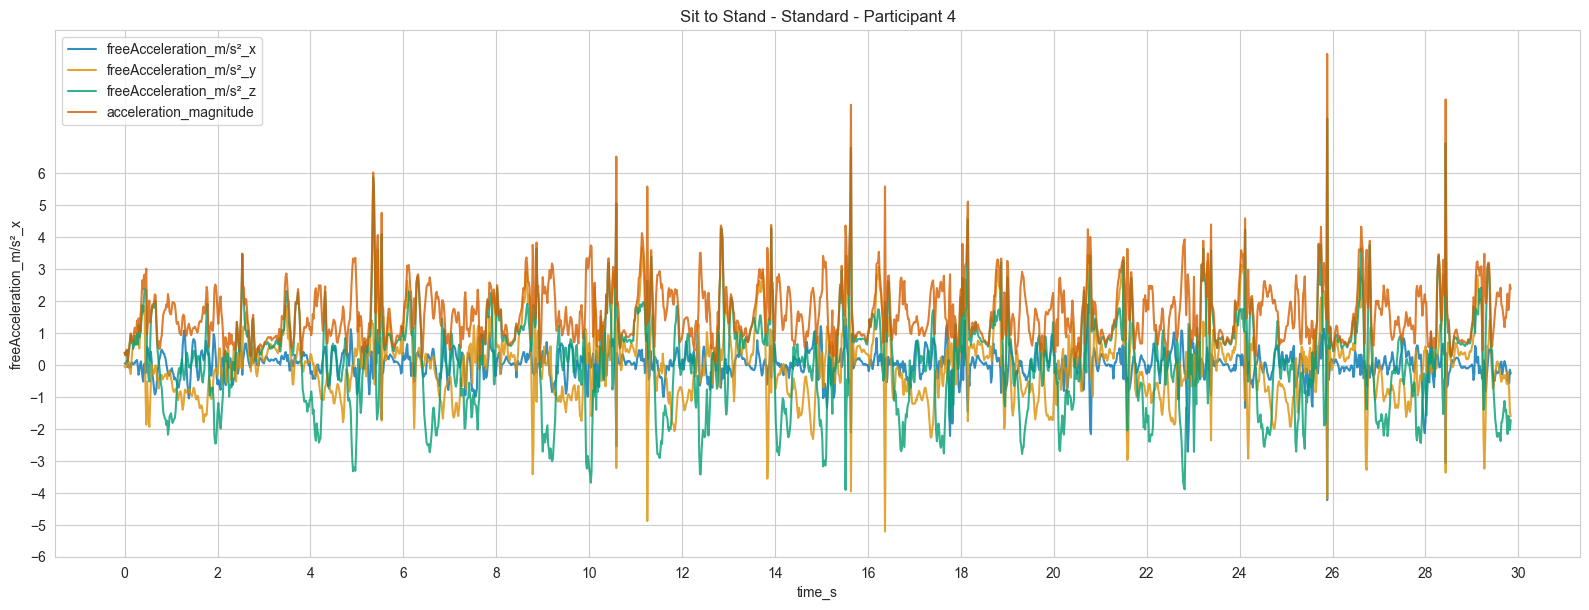

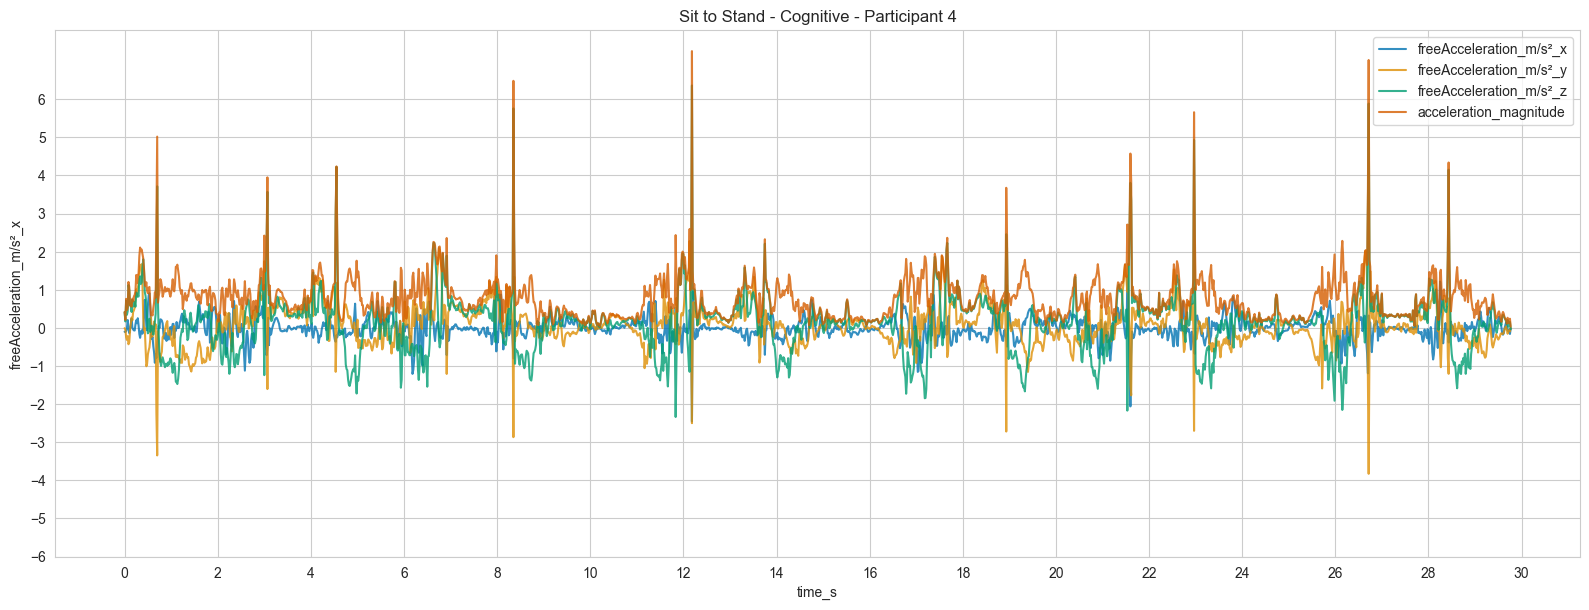

KeyboardInterrupt: 

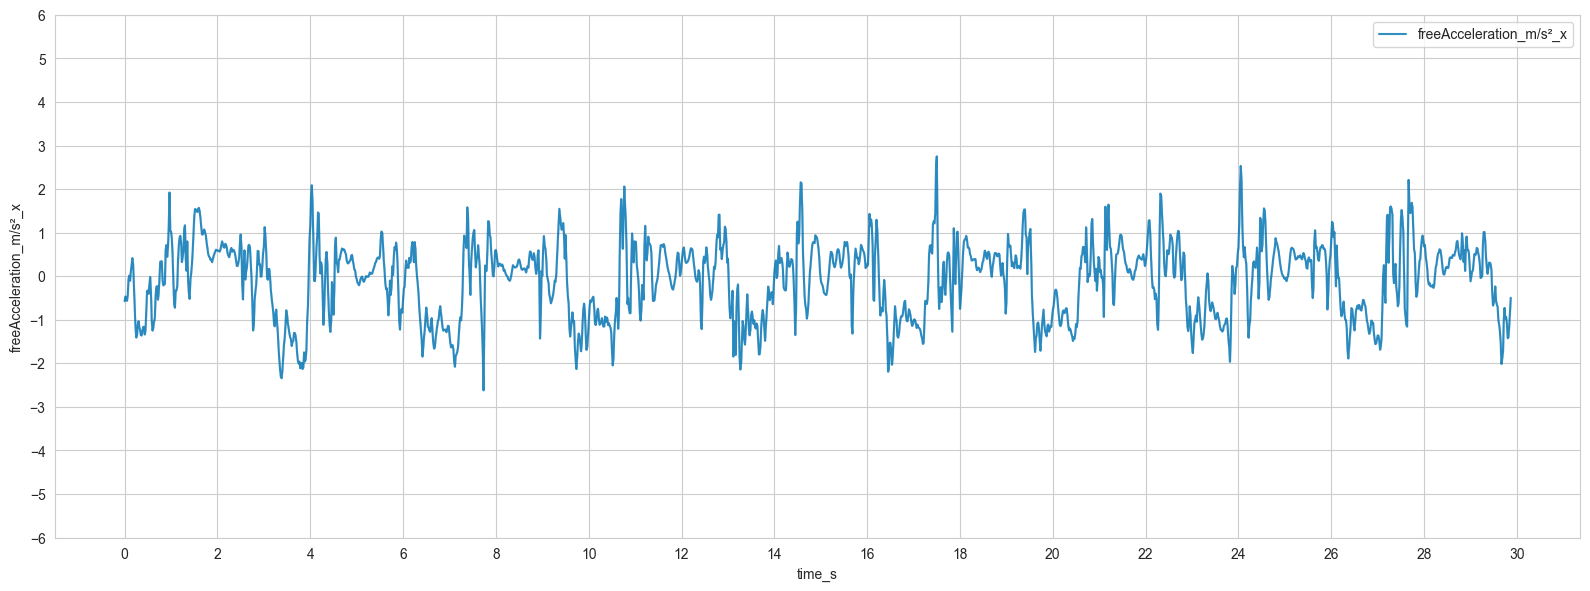

In [39]:
for i in range(len(dfs_sit_to_stand_yes_preprocessed)):
    plot_column_sns(dfs_sit_to_stand_no_preprocessed[i], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z', 'acceleration_magnitude'], f'Sit to Stand - Standard - Participant {i+1}')
    plot_column_sns(dfs_sit_to_stand_yes_preprocessed[i], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z', 'acceleration_magnitude'], f'Sit to Stand - Cognitive - Participant {i+1}')
    
    


# Peak finding

In [10]:
# Calculate the troughs and peaks of the velocity_z
from scipy.signal import find_peaks

def calculate_peaks_and_troughs(df, column_name):
    peaks, _ = find_peaks(df[column_name], distance=20, prominence=0.5)
    troughs, _ = find_peaks(-df[column_name], distance=20, prominence=0.5)
    return peaks, troughs


In [11]:
def calculate_and_plot_peaks_and_troughs(df, column_name):
    import matplotlib.pyplot as plt
    peaks, troughs = calculate_peaks_and_troughs(df, column_name)
    plt.figure(figsize=(26, 8))
    plt.plot(df['time_s'], df[column_name])
    plt.scatter(df['time_s'][peaks], df[column_name][peaks], color='red', label='Peaks', marker='x')
    plt.scatter(df['time_s'][troughs], df[column_name][troughs], color='blue', label='Troughs', marker='x')
    plt.legend()
    plt.title(f'{column_name} Peaks and Troughs')



<Figure size 3000x800 with 0 Axes>

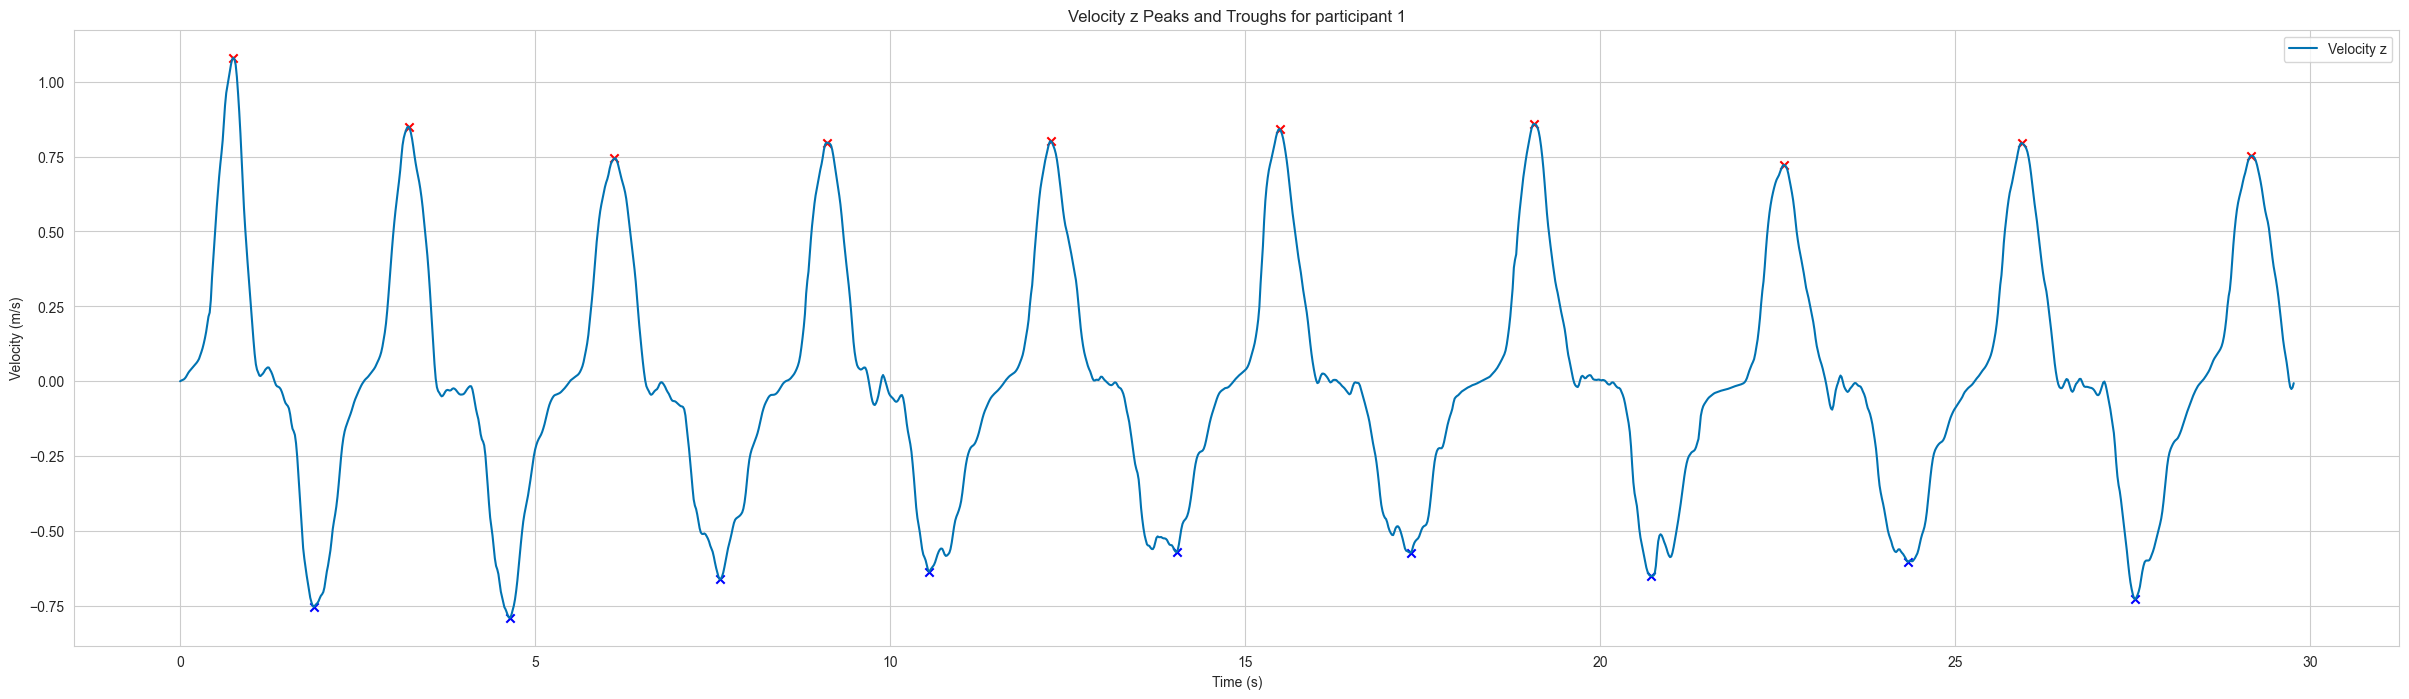

Participant 1 has 2 peaks and 3 troughs along x axis
Participant 1 has 8 peaks and 9 troughs along y axis
Participant 1 has 10 peaks and 9 troughs along z axis


<Figure size 3000x800 with 0 Axes>

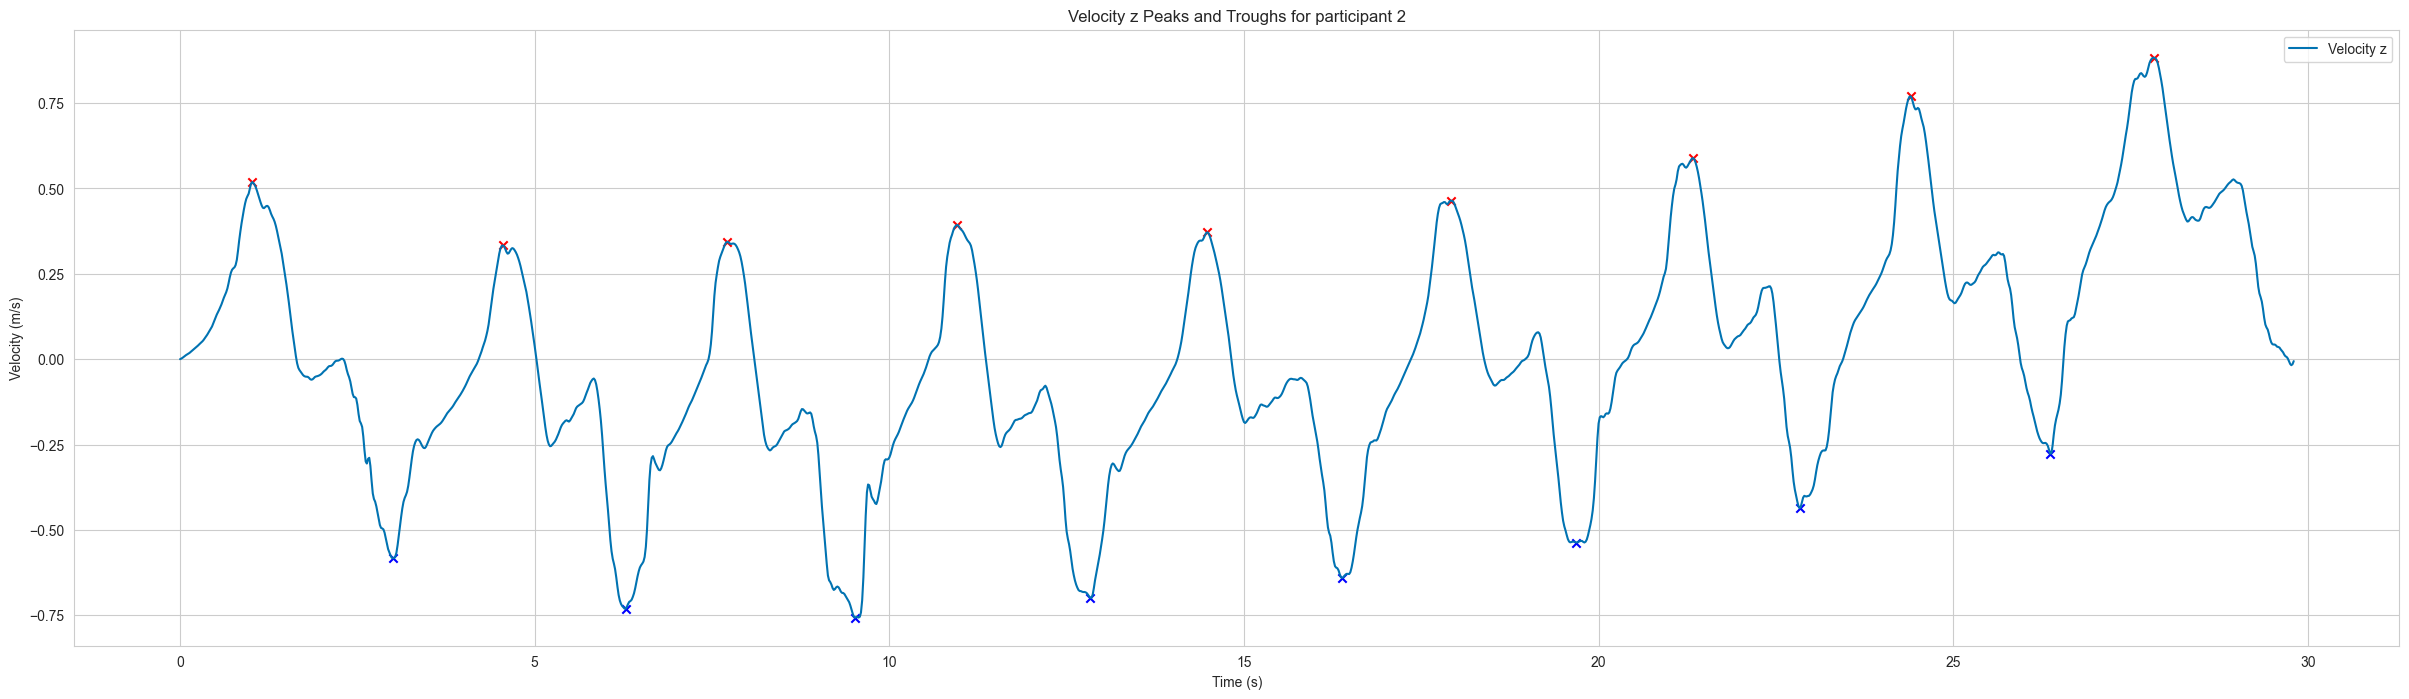

Participant 2 has 1 peaks and 1 troughs along x axis
Participant 2 has 8 peaks and 8 troughs along y axis
Participant 2 has 9 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

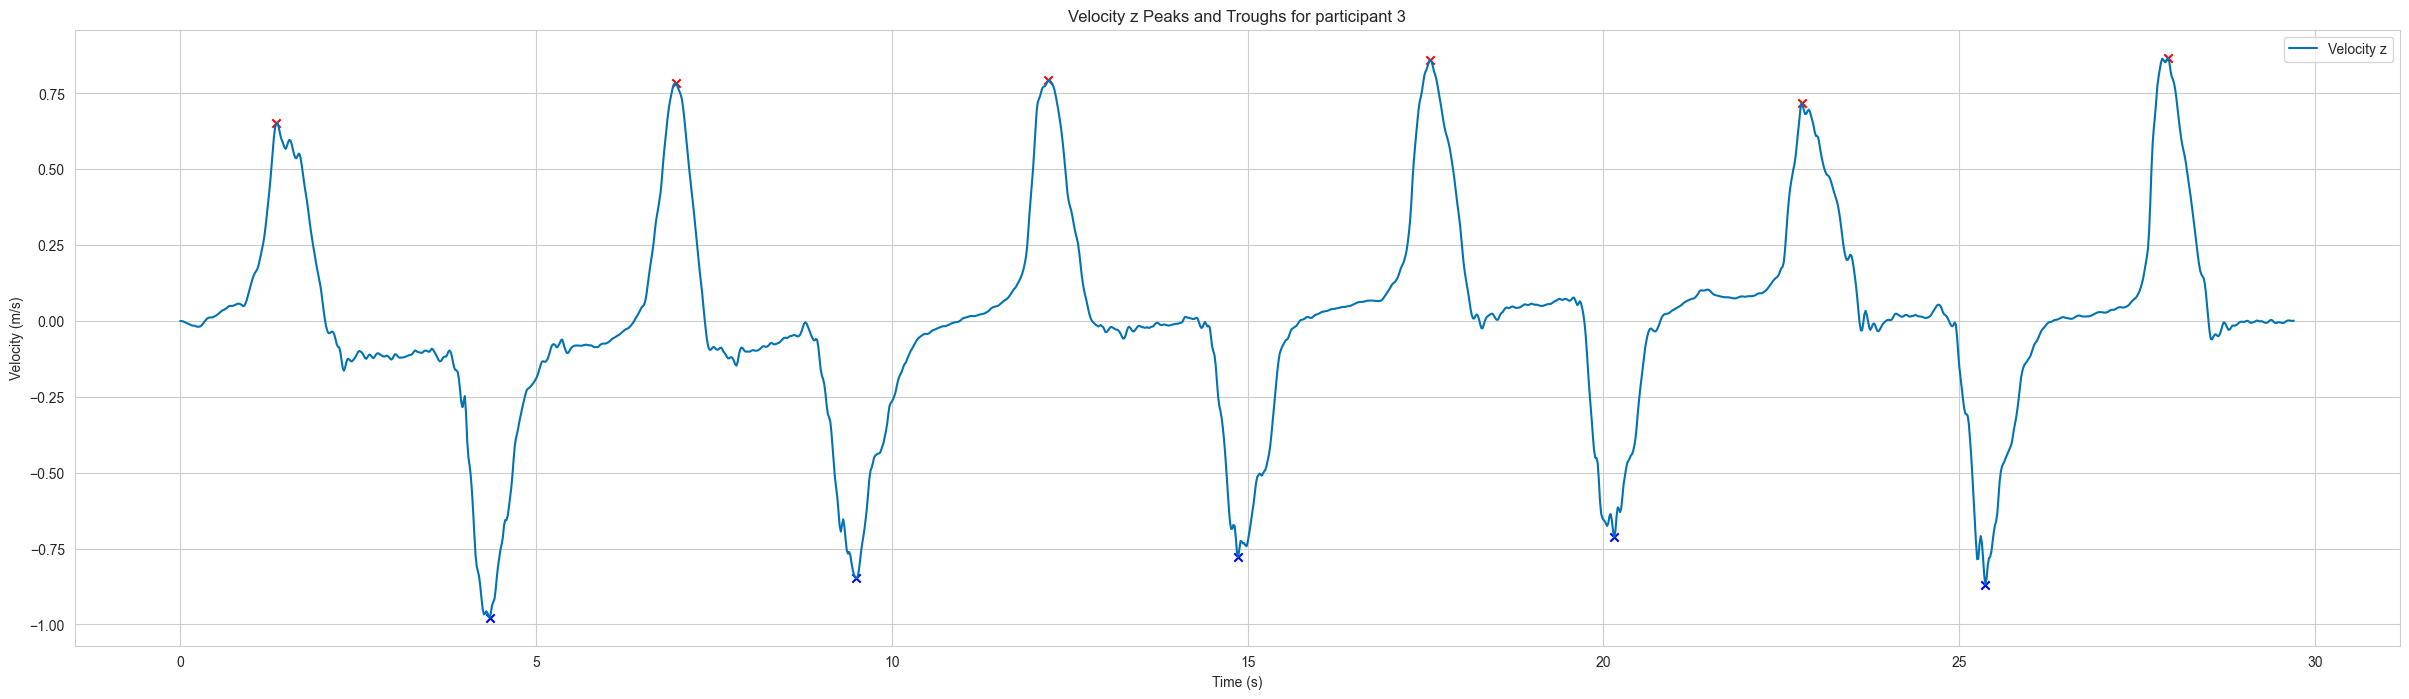

Participant 3 has 5 peaks and 5 troughs along x axis
Participant 3 has 1 peaks and 0 troughs along y axis
Participant 3 has 6 peaks and 5 troughs along z axis


<Figure size 3000x800 with 0 Axes>

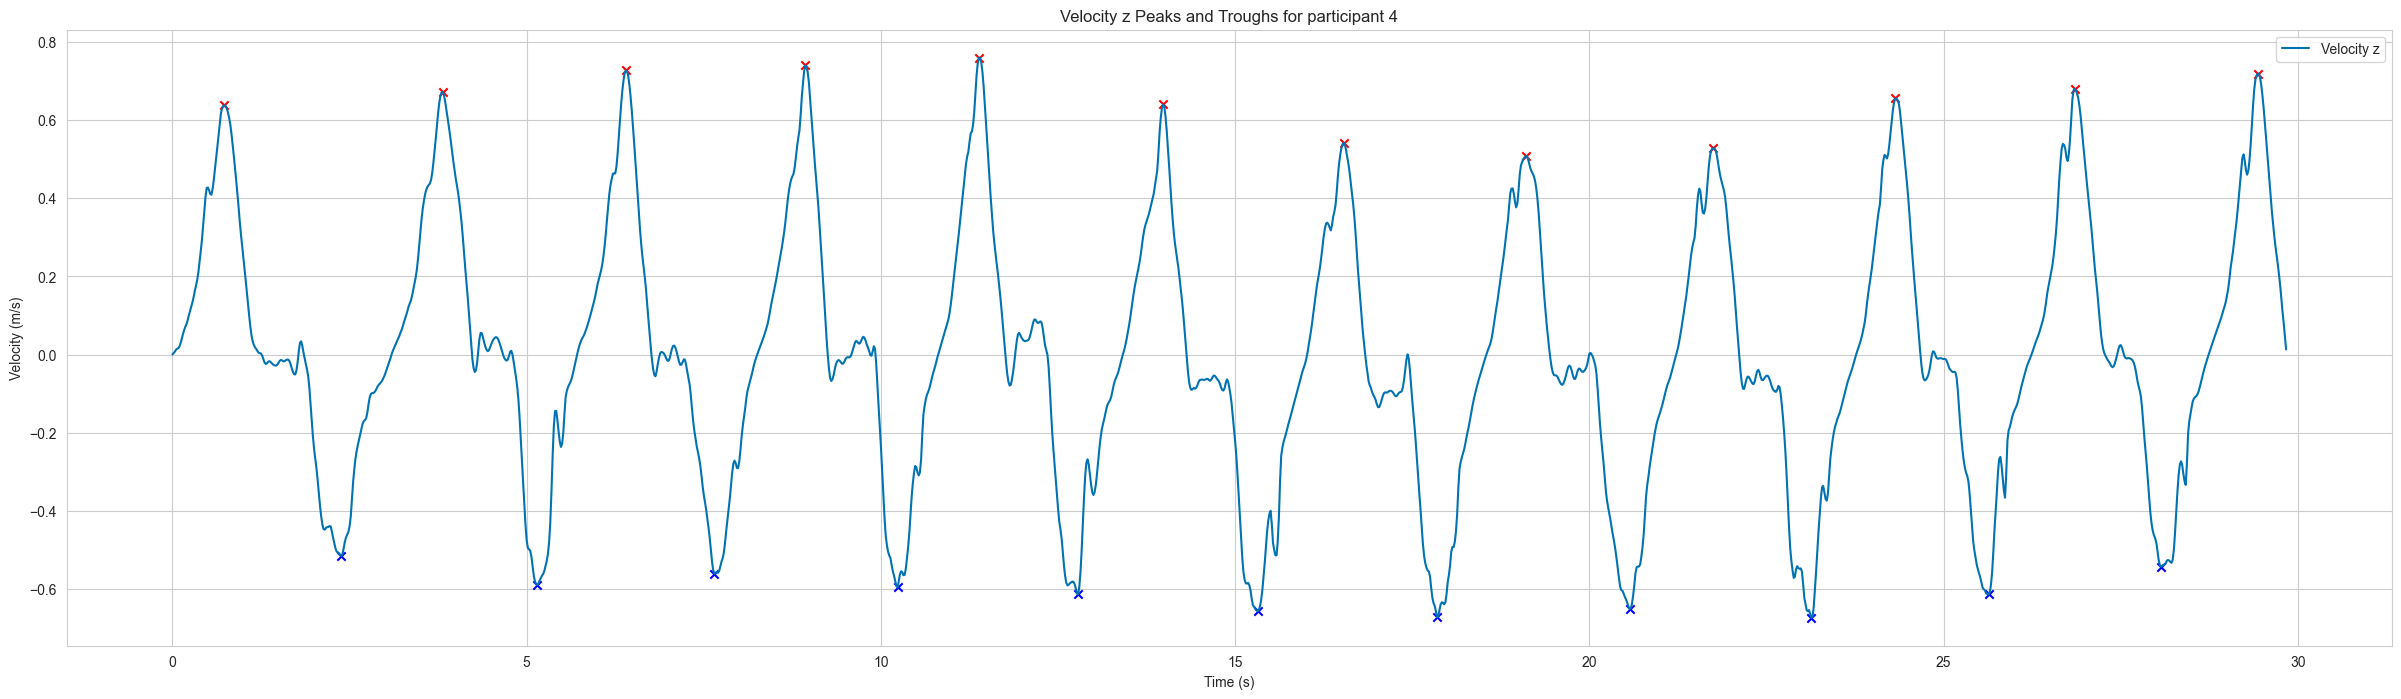

Participant 4 has 0 peaks and 0 troughs along x axis
Participant 4 has 10 peaks and 11 troughs along y axis
Participant 4 has 12 peaks and 11 troughs along z axis


<Figure size 3000x800 with 0 Axes>

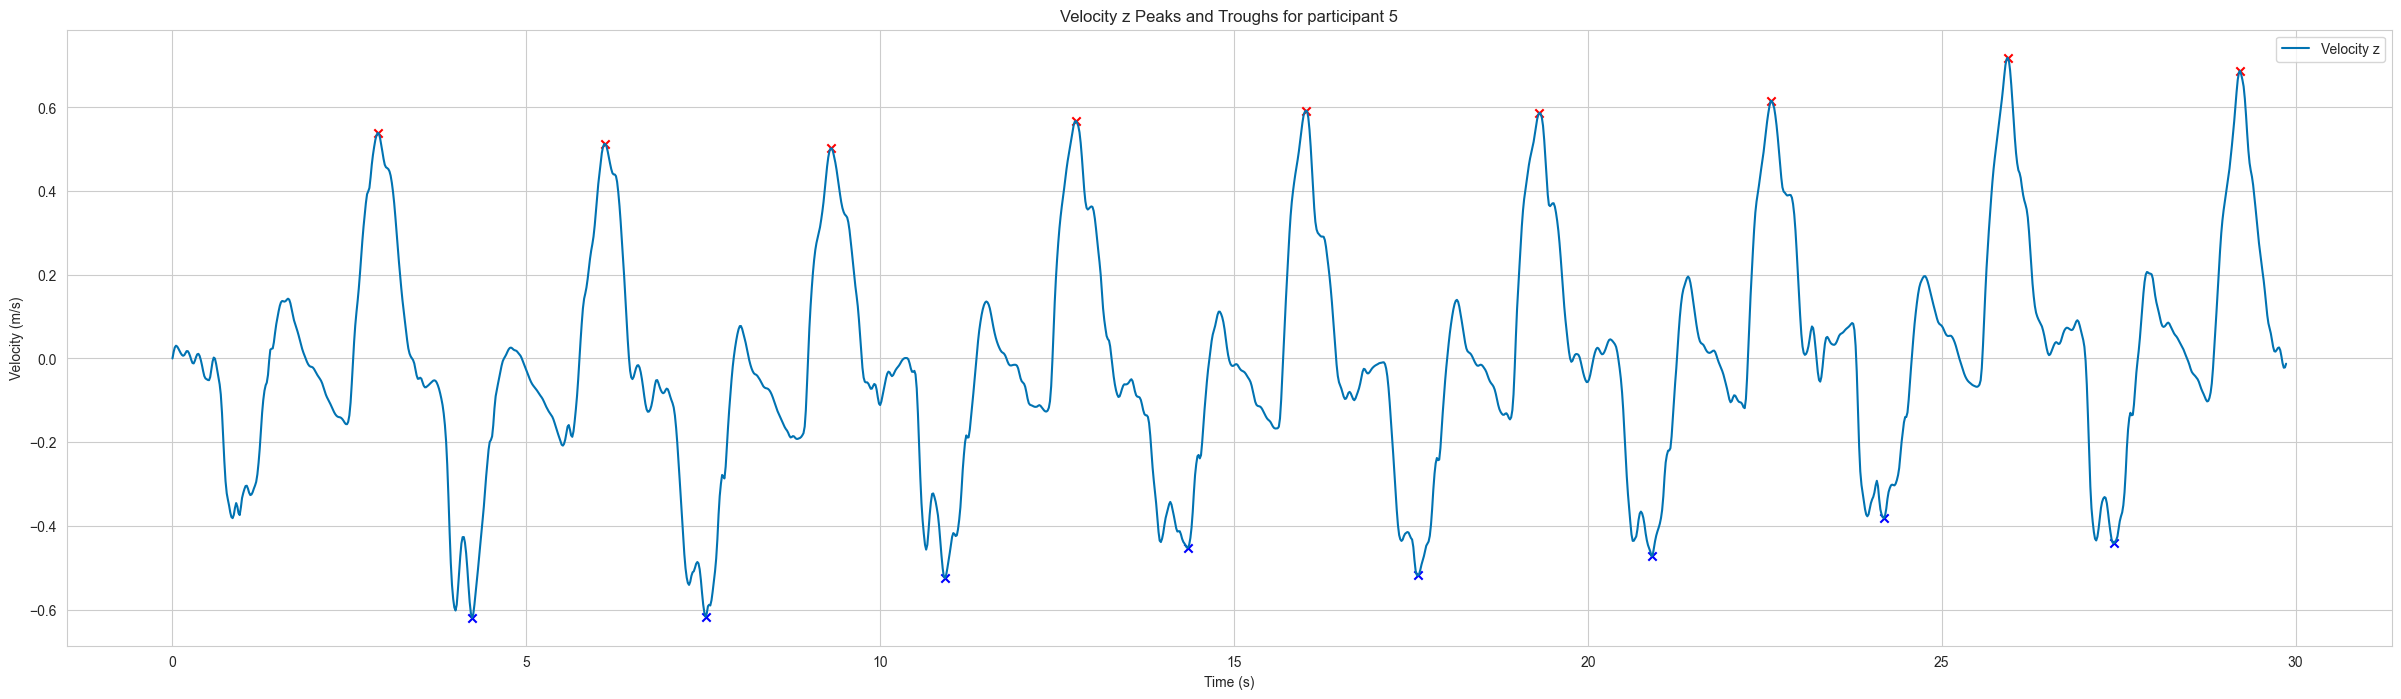

Participant 5 has 8 peaks and 8 troughs along x axis
Participant 5 has 7 peaks and 7 troughs along y axis
Participant 5 has 9 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

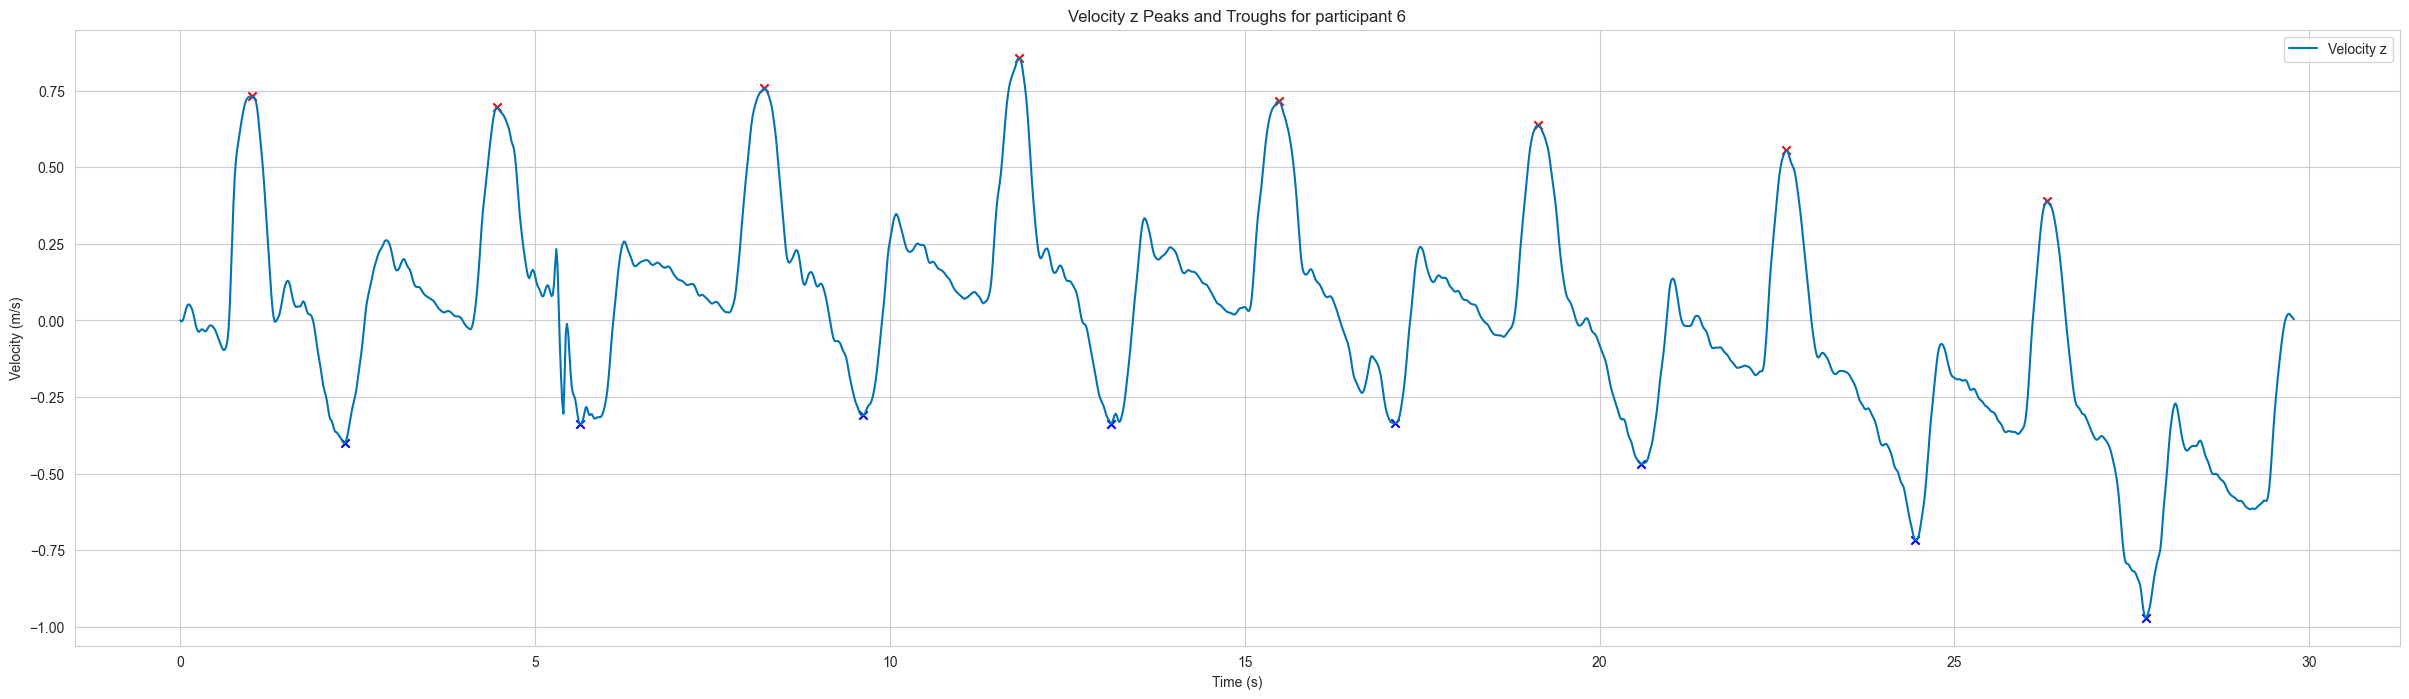

Participant 6 has 7 peaks and 7 troughs along x axis
Participant 6 has 1 peaks and 0 troughs along y axis
Participant 6 has 8 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

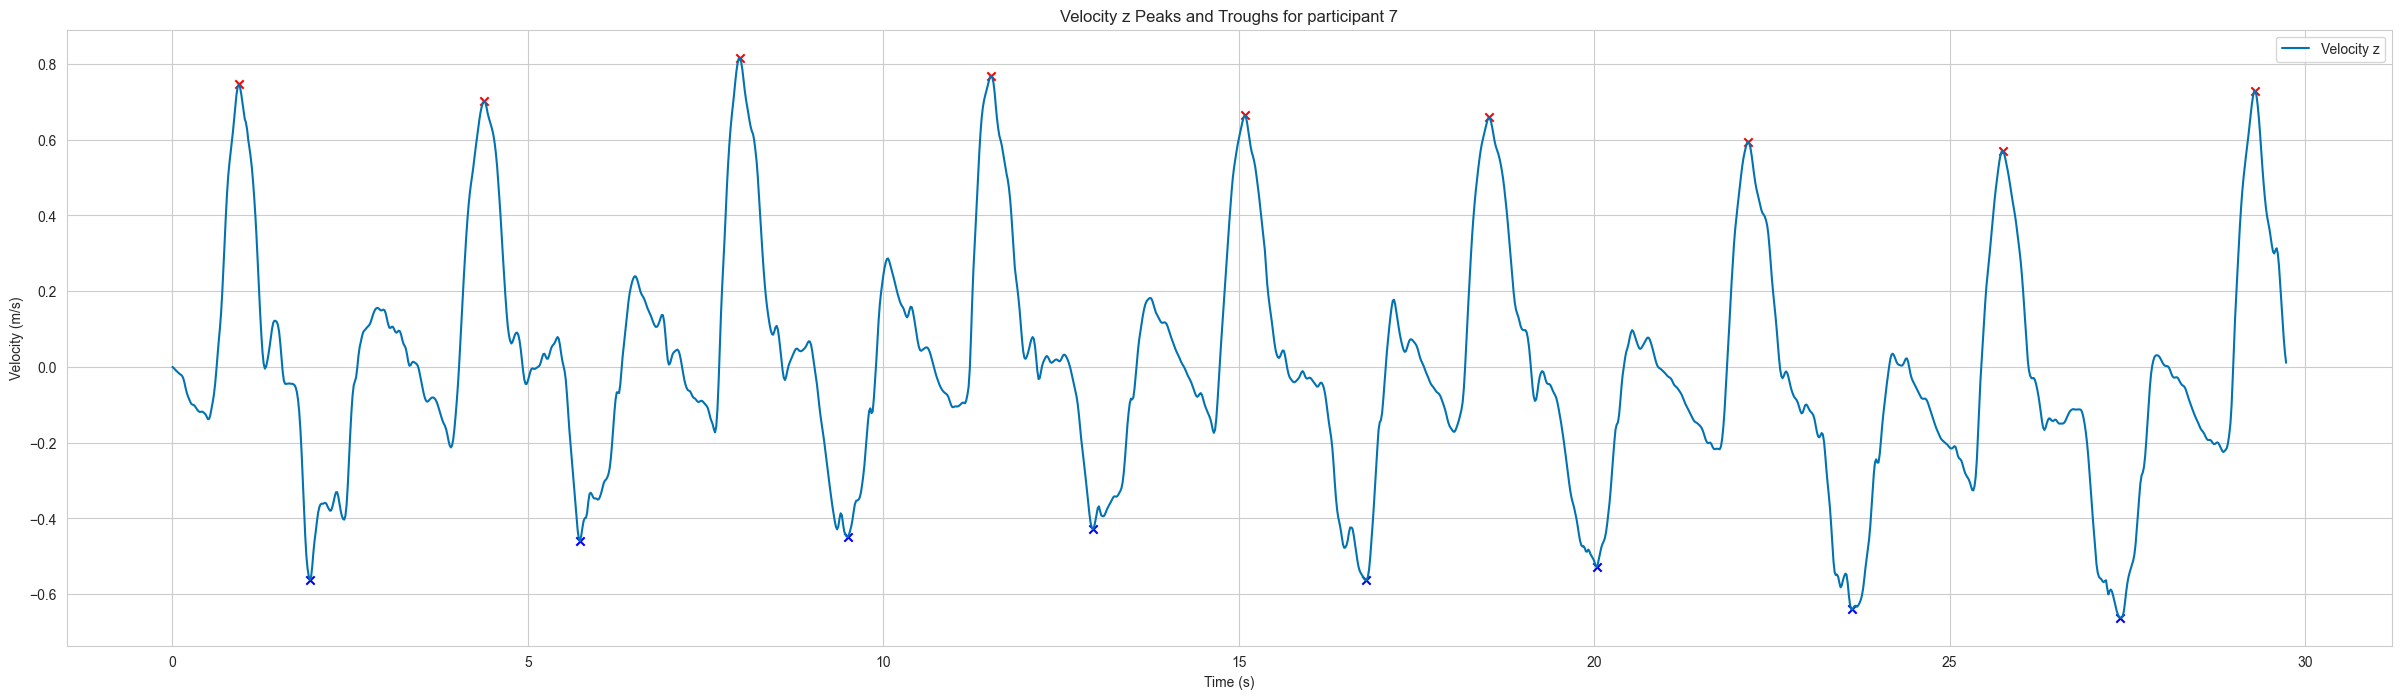

Participant 7 has 7 peaks and 8 troughs along x axis
Participant 7 has 0 peaks and 0 troughs along y axis
Participant 7 has 9 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

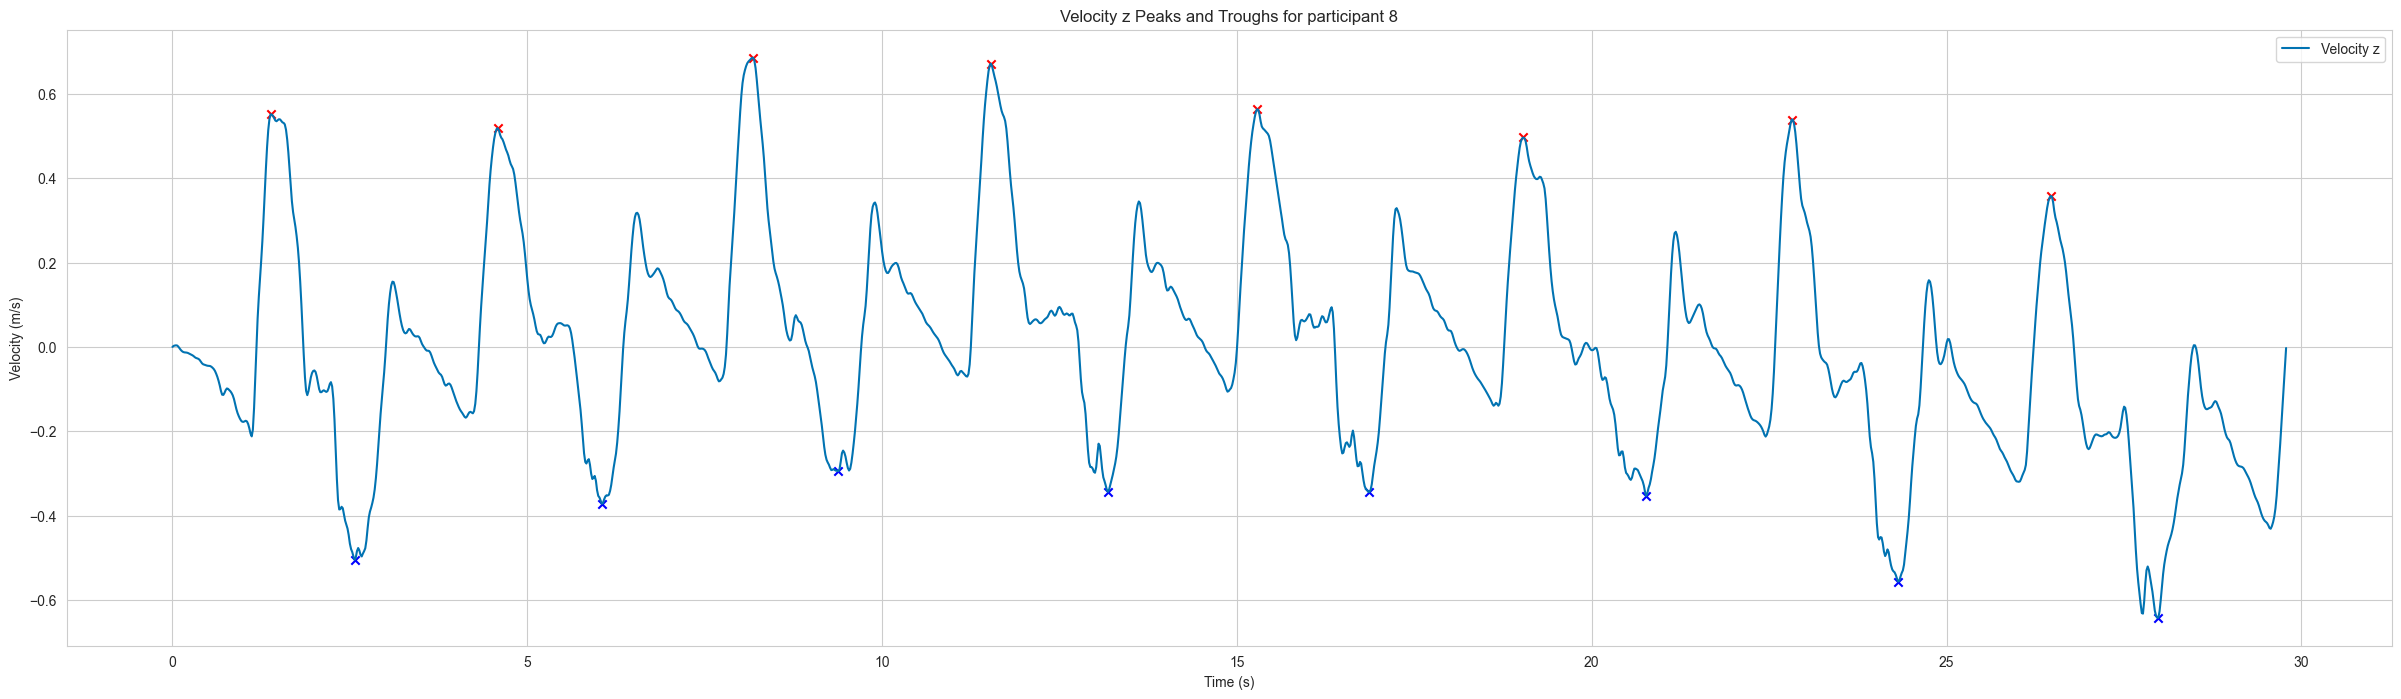

Participant 8 has 8 peaks and 8 troughs along x axis
Participant 8 has 7 peaks and 7 troughs along y axis
Participant 8 has 8 peaks and 8 troughs along z axis


<Figure size 3000x800 with 0 Axes>

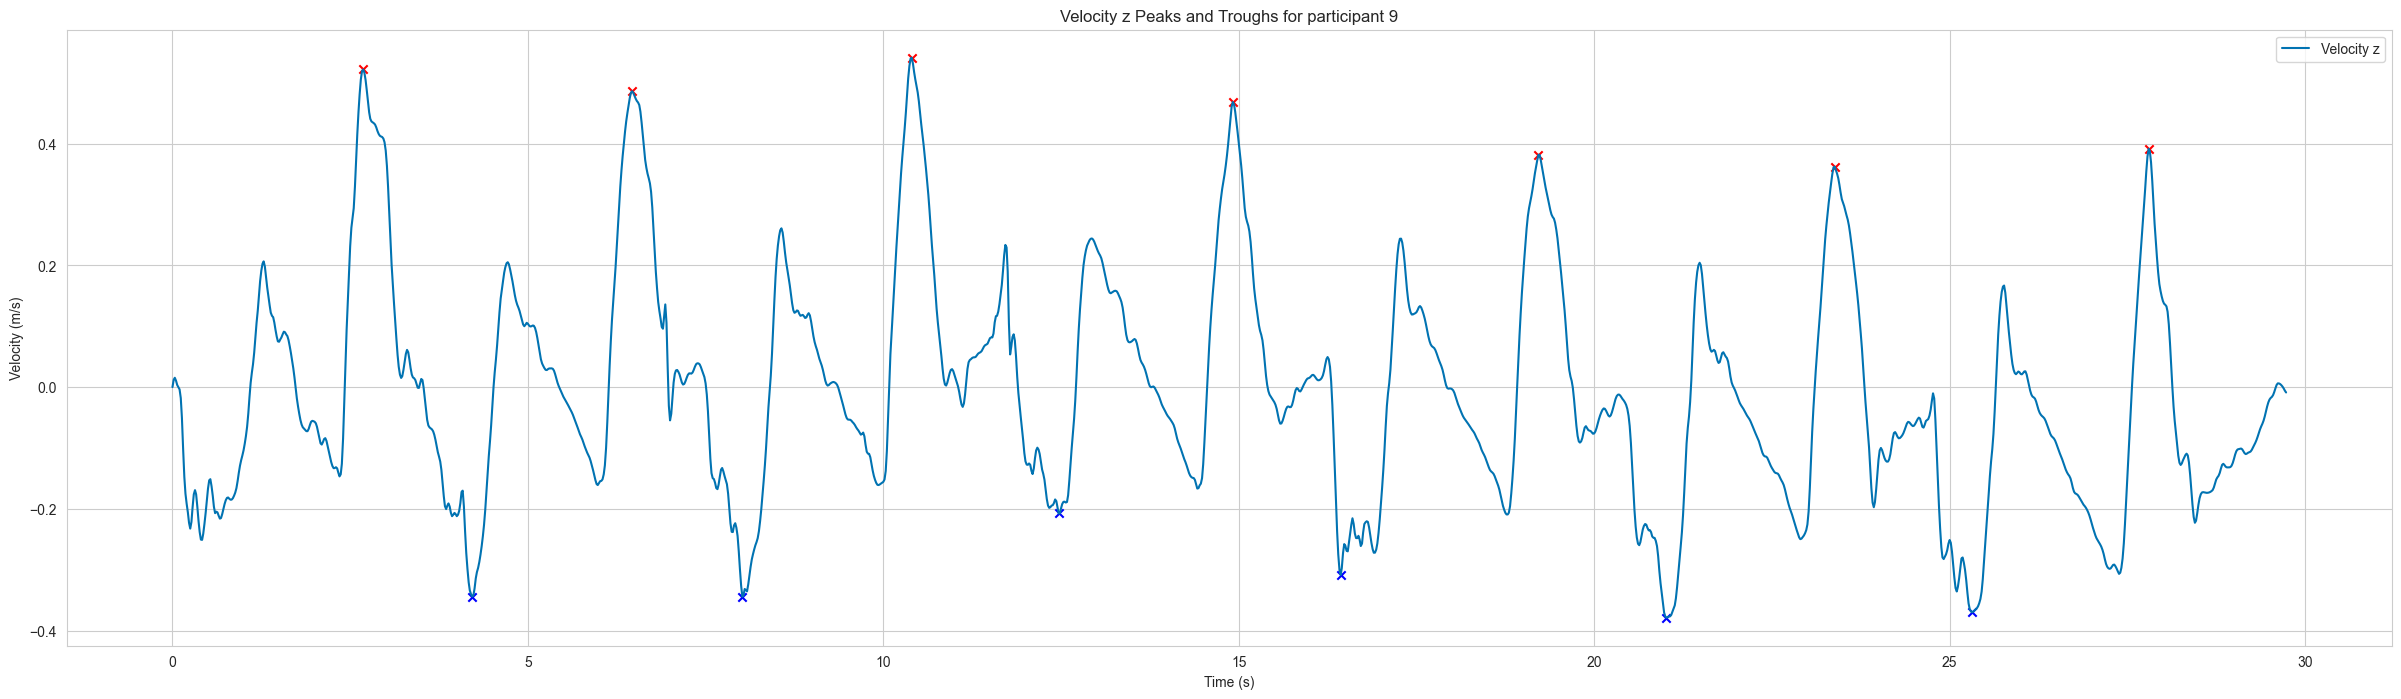

Participant 9 has 6 peaks and 5 troughs along x axis
Participant 9 has 1 peaks and 2 troughs along y axis
Participant 9 has 7 peaks and 6 troughs along z axis


<Figure size 3000x800 with 0 Axes>

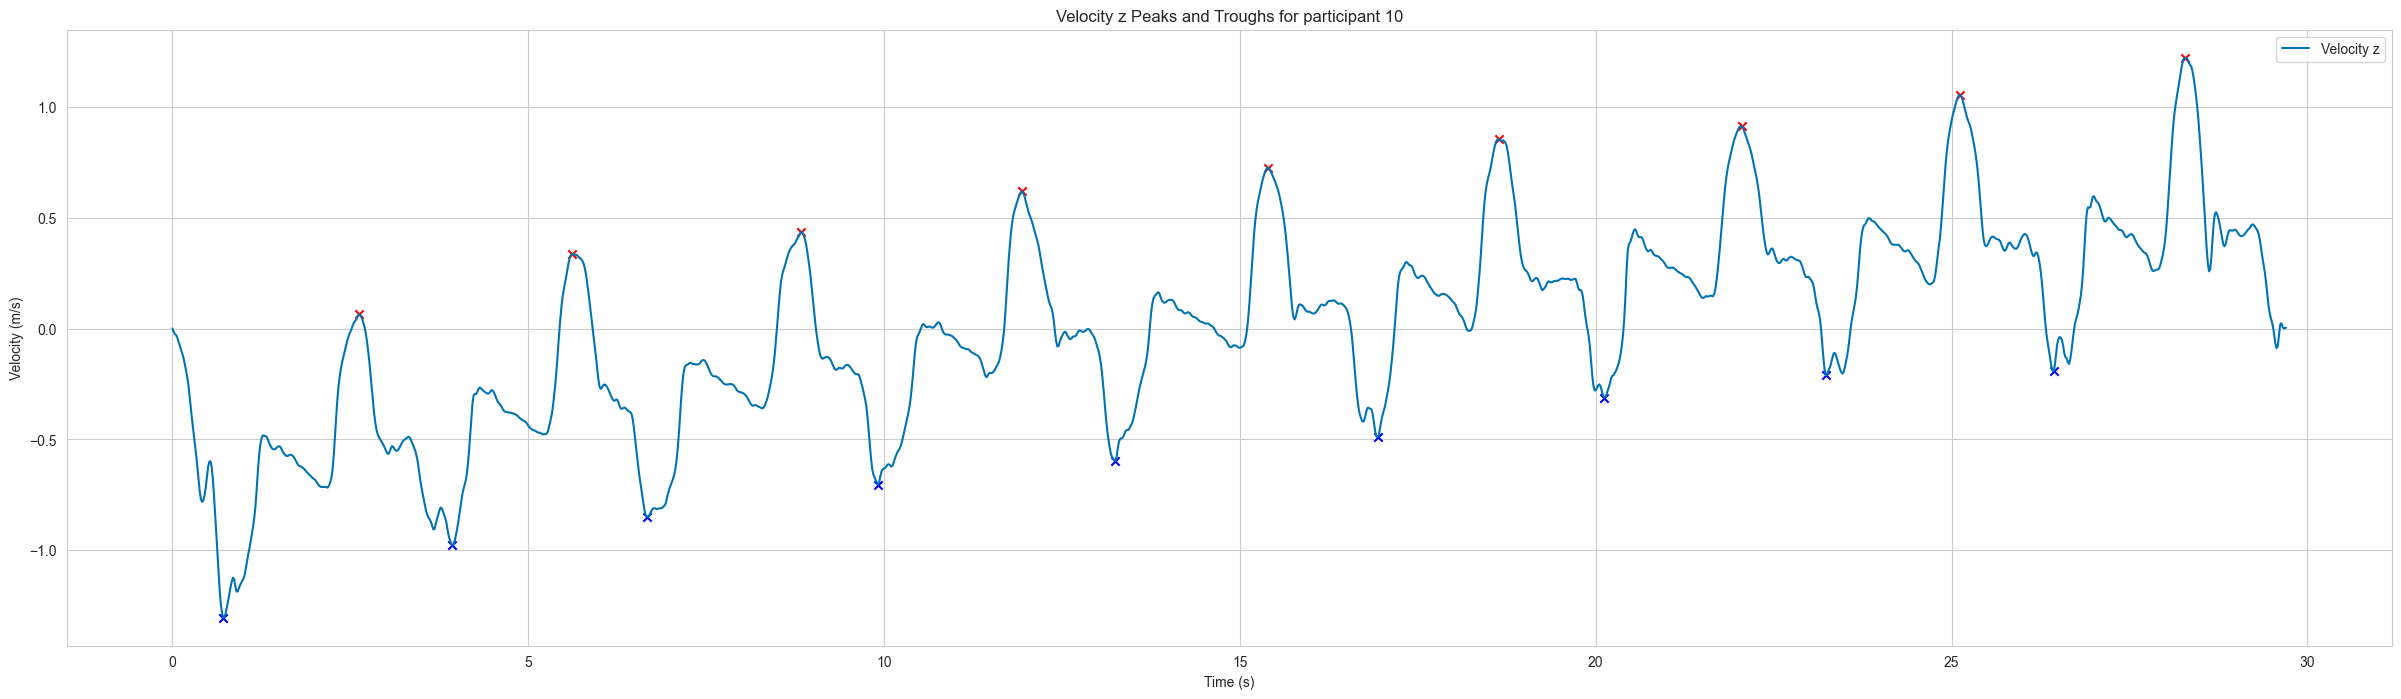

Participant 10 has 1 peaks and 1 troughs along x axis
Participant 10 has 8 peaks and 8 troughs along y axis
Participant 10 has 9 peaks and 9 troughs along z axis


In [ ]:
# For each participant in dfs_stand, calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
for i, dataframe in enumerate(dfs_sit_to_stand_no_preprocessed):
    import matplotlib.pyplot as plt
    # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y

    plot_others = False
    # Make the plots more beautiful and academic
    plt.figure(figsize=(30, 8))


    plt.figure(figsize=(30, 8))
    # Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively
    standard_peaks_x, standard_troughs_x = calculate_peaks_and_troughs(dataframe, 'velocity_x')
    standard_peaks_y, standard_troughs_y = calculate_peaks_and_troughs(dataframe, 'velocity_y')
    standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(dataframe, 'velocity_z')

    plt.plot(dataframe['time_s'], dataframe['velocity_z'], label='Velocity z')
    plt.scatter(dataframe['time_s'][standard_peaks_z], dataframe['velocity_z'][standard_peaks_z], color='red', marker='x')
    plt.scatter(dataframe['time_s'][standard_troughs_z], dataframe['velocity_z'][standard_troughs_z], color='blue', marker='x')

    if plot_others:
        # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively

        plt.plot(dataframe['time_s'], dataframe['velocity_y'], label='Velocity y')
        plt.scatter(dataframe['time_s'][standard_peaks_y], dataframe['velocity_y'][standard_peaks_y], color='red', marker='x')
        plt.scatter(dataframe['time_s'][standard_troughs_y], dataframe['velocity_y'][standard_troughs_y], color='blue', marker='x')

        plt.plot(dataframe['time_s'], dataframe['velocity_x'], label='Velocity x')
        plt.scatter(dataframe['time_s'][standard_peaks_x], dataframe['velocity_x'][standard_peaks_x], color='red', marker='x')
        plt.scatter(dataframe['time_s'][standard_troughs_x], dataframe['velocity_x'][standard_troughs_x], color='blue', marker='x')

        plt.plot(dataframe['time_s'], dataframe['velocity_magnitude'], label='Velocity magnitude', color='black')

    plt.legend()
    plt.title(f'Velocity z Peaks and Troughs for participant {i+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.show()

    print(f"Participant {i+1} has {len(standard_peaks_x)} peaks and {len(standard_troughs_x)} troughs along x axis")
    print(f"Participant {i+1} has {len(standard_peaks_y)} peaks and {len(standard_troughs_y)} troughs along y axis")
    print(f'Participant {i+1} has {len(standard_peaks_z)} peaks and {len(standard_troughs_z)} troughs along z axis')
    
    



In [13]:
for i in range(len(dfs_sit_to_stand_no)):
    print(len(dfs_sit_to_stand_yes_preprocessed[i]), len(dfs_sit_to_stand_no_preprocessed[i]))

1787 1787
1787 1789
1785 1783
1787 1791
3596 3586
1783 1788
1787 1785
3583 3575
3575 3569
1787 1783


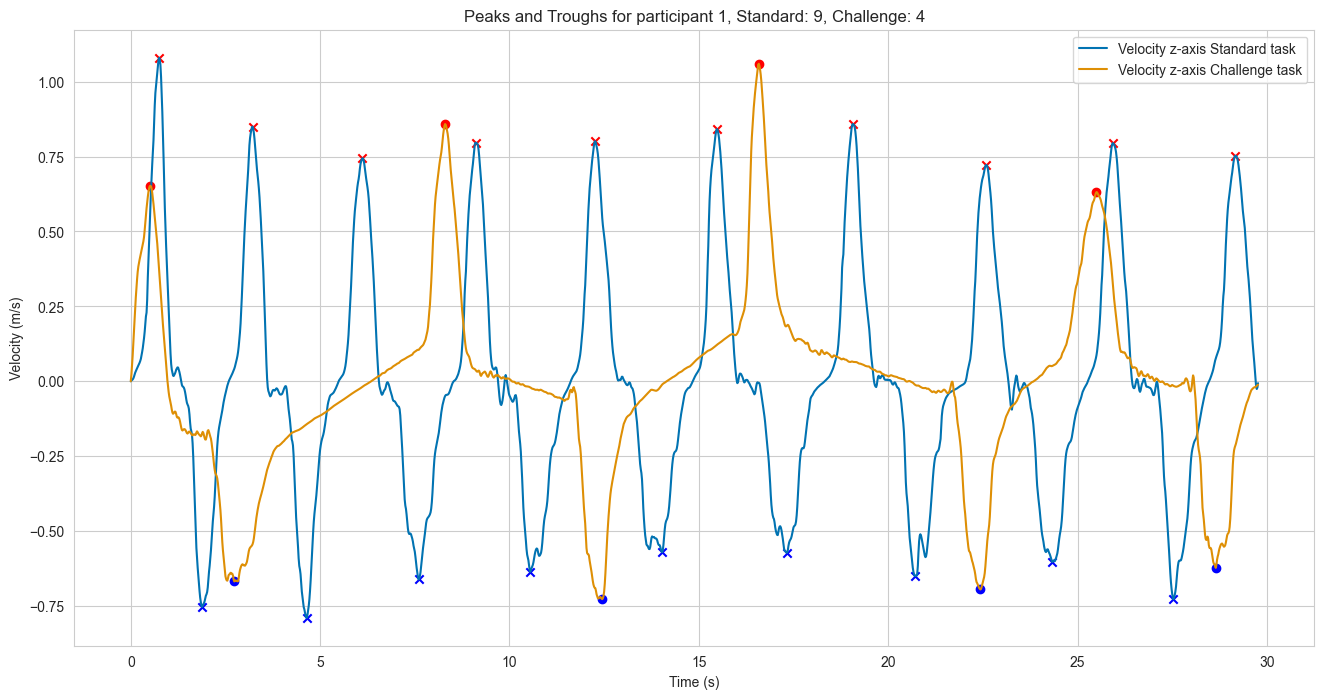

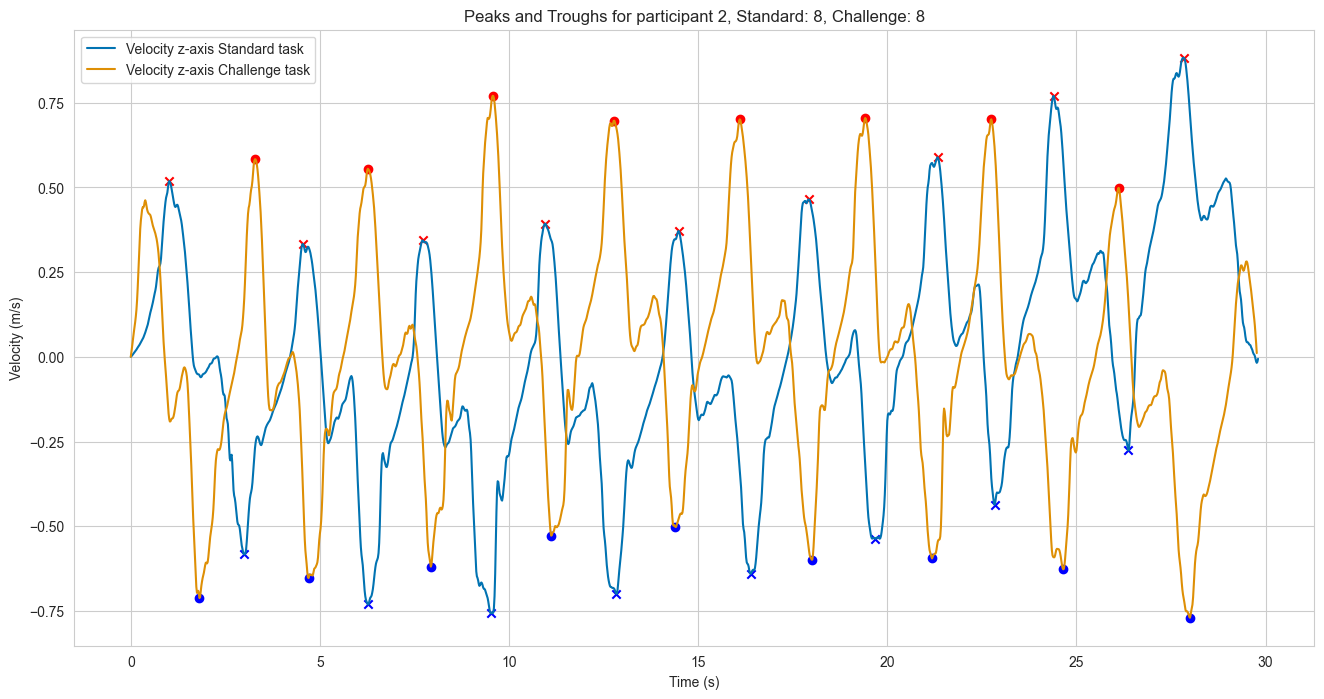

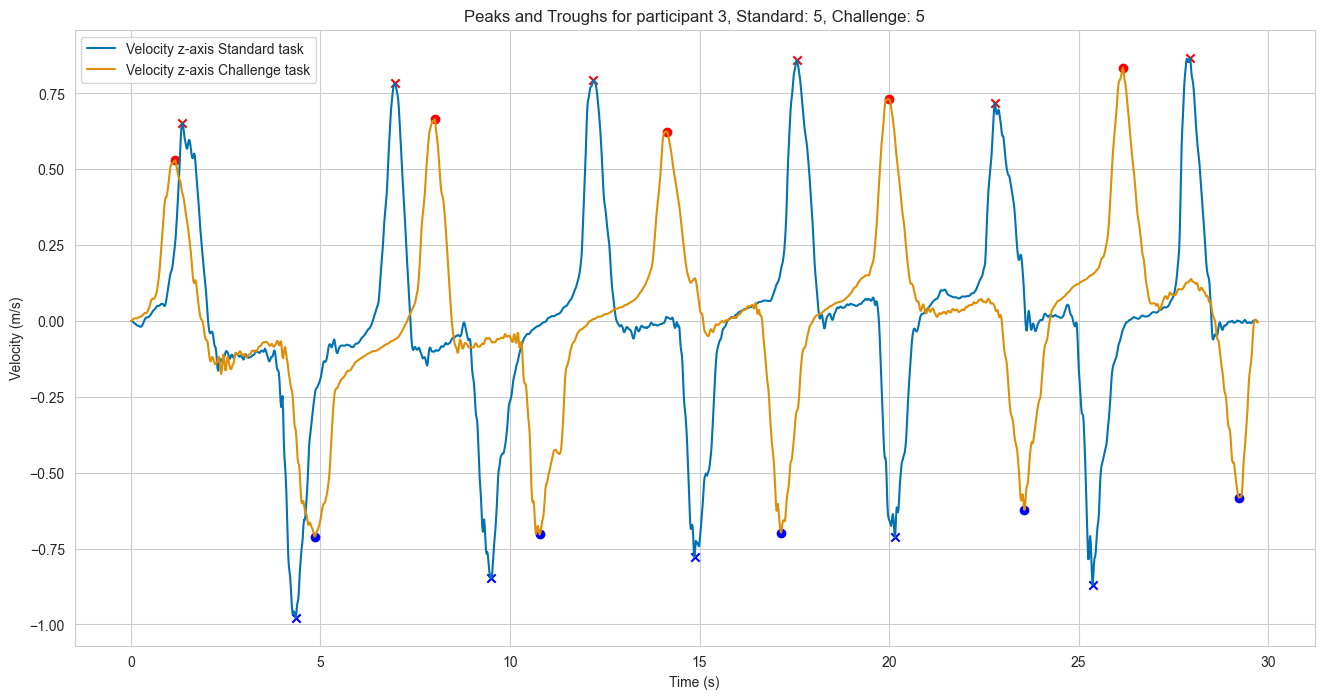

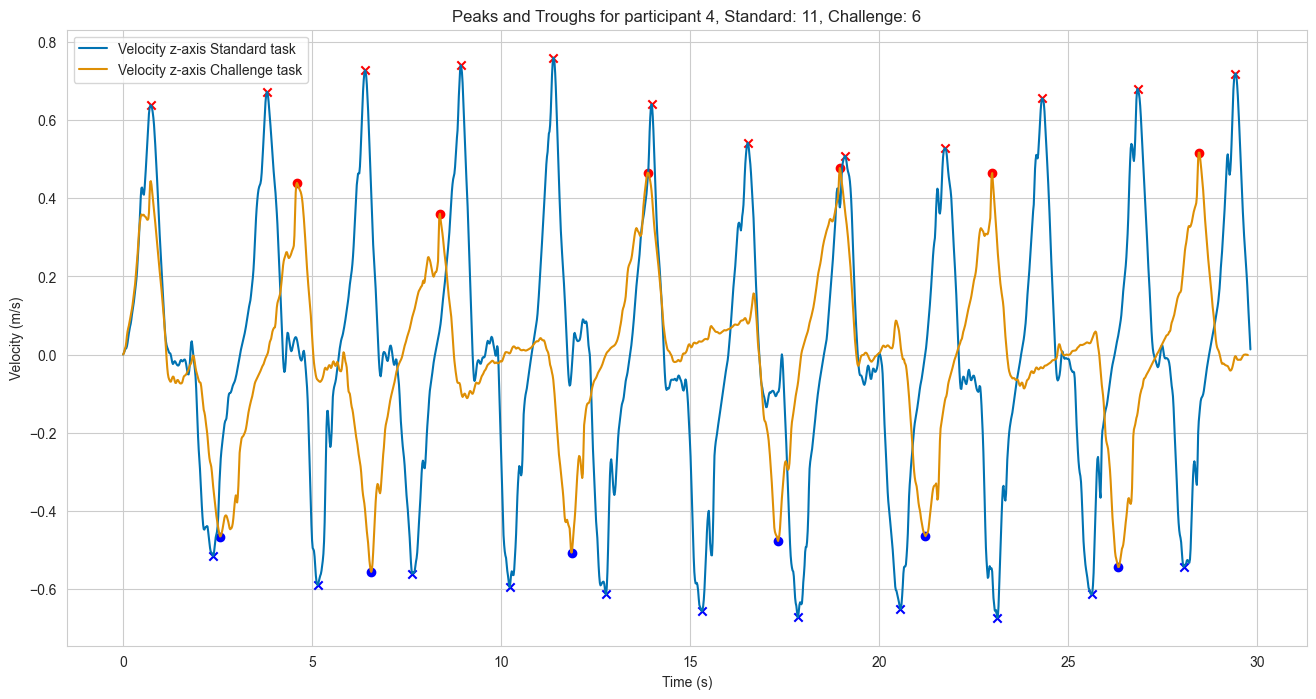

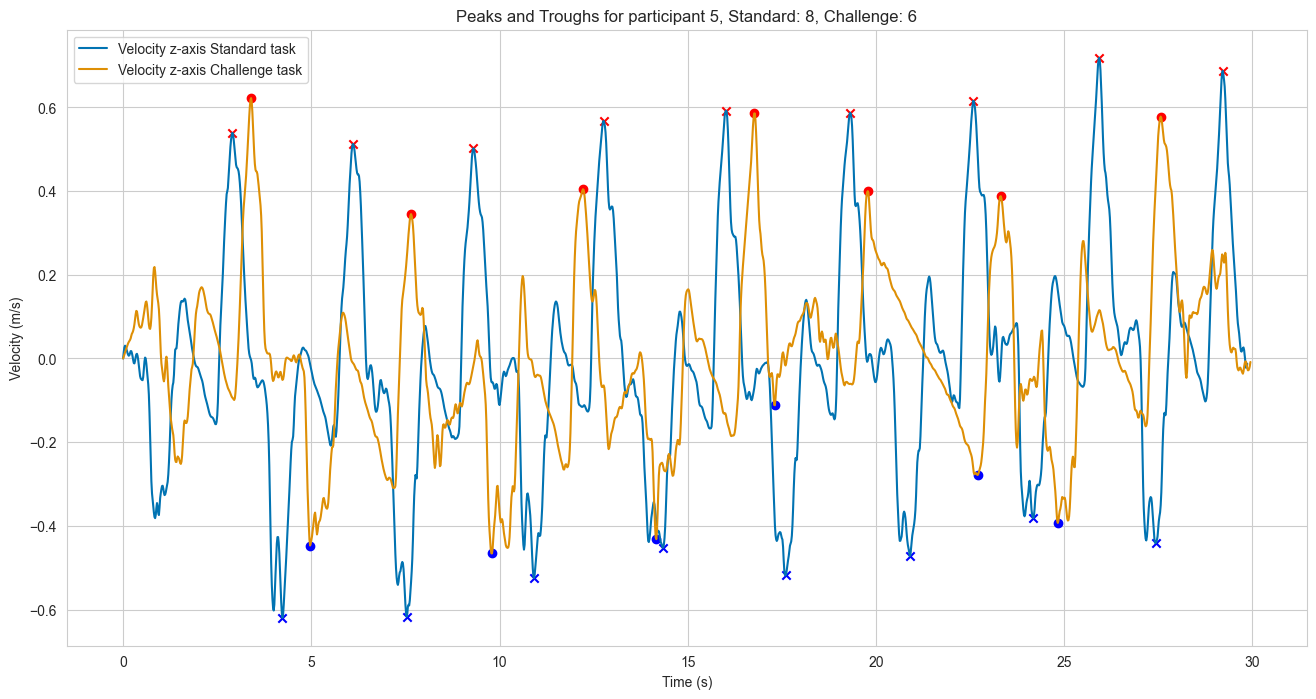

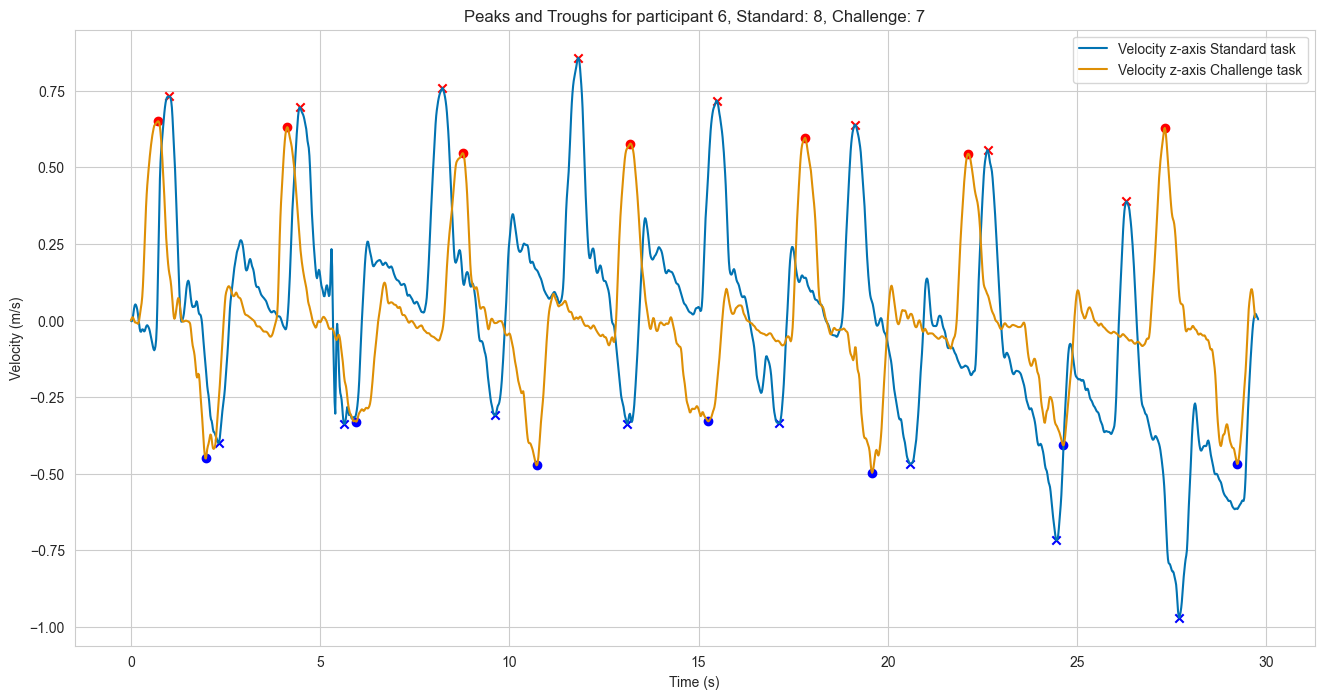

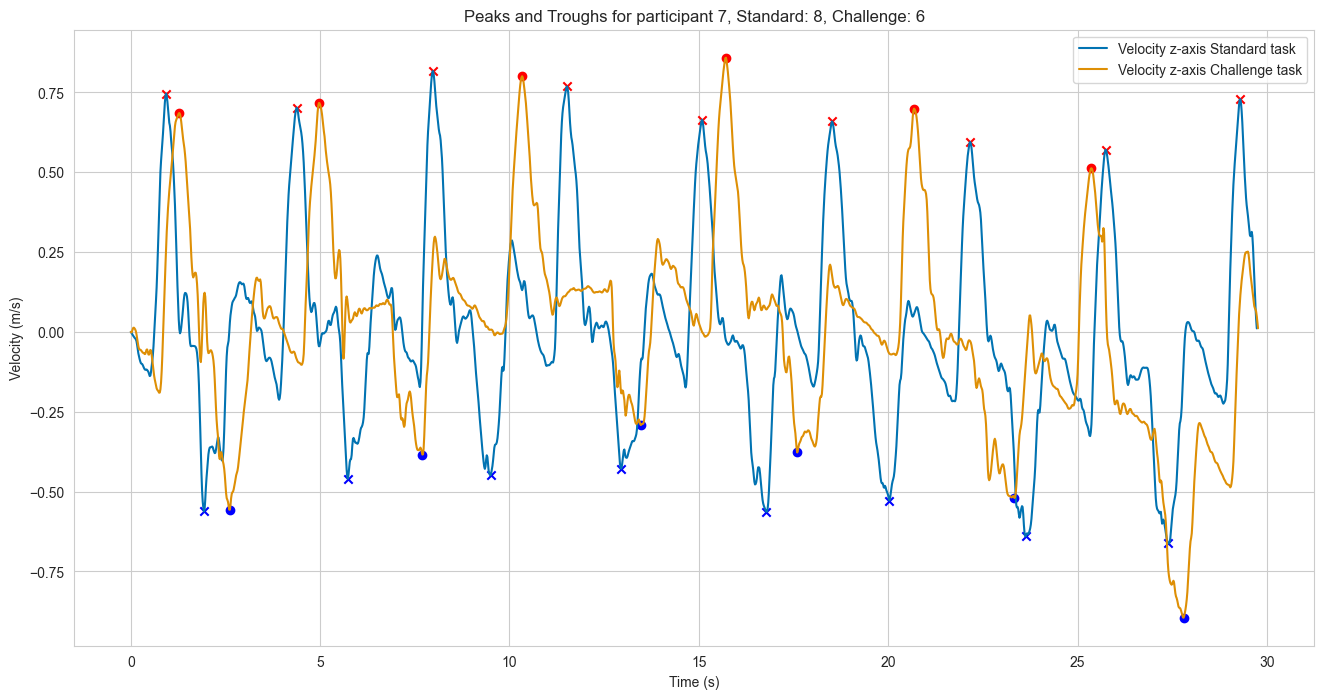

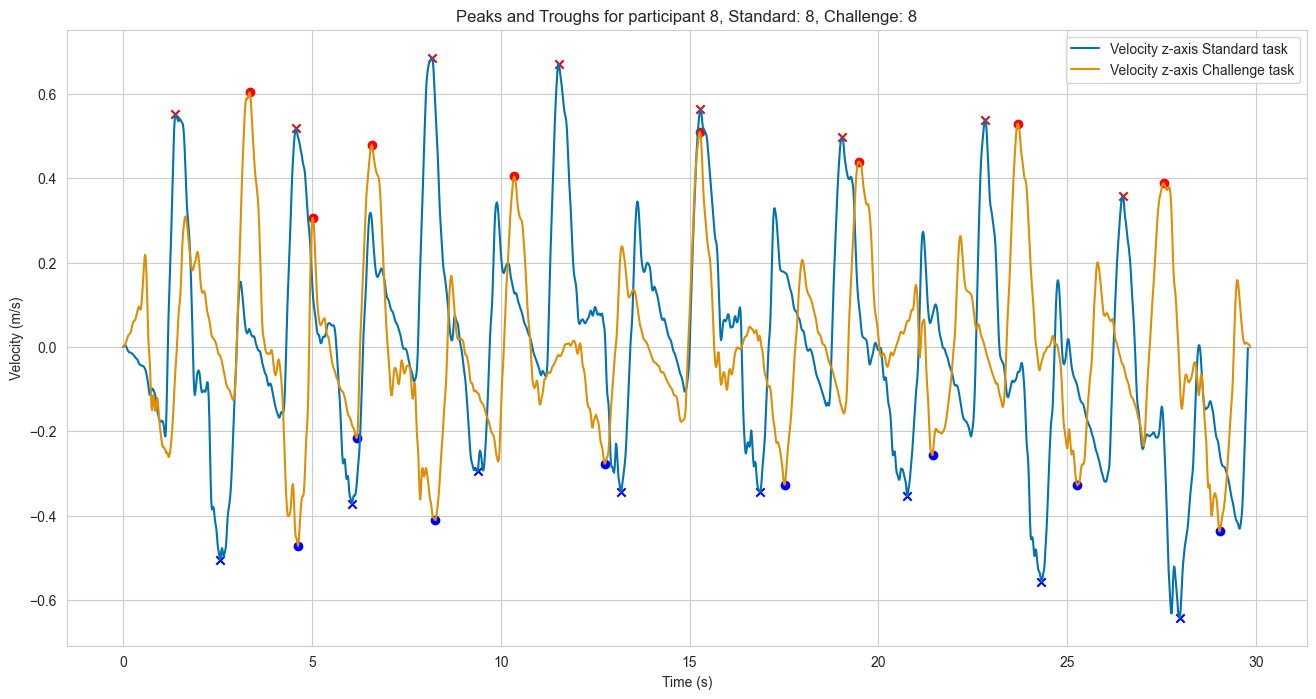

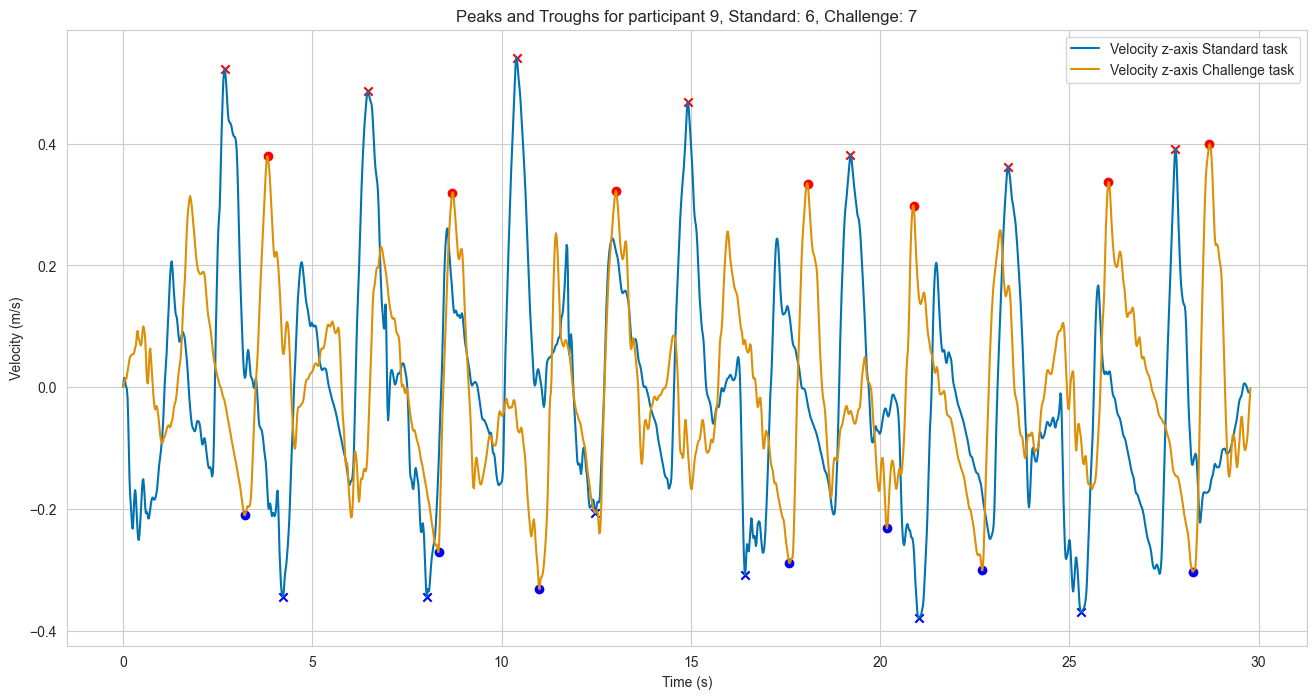

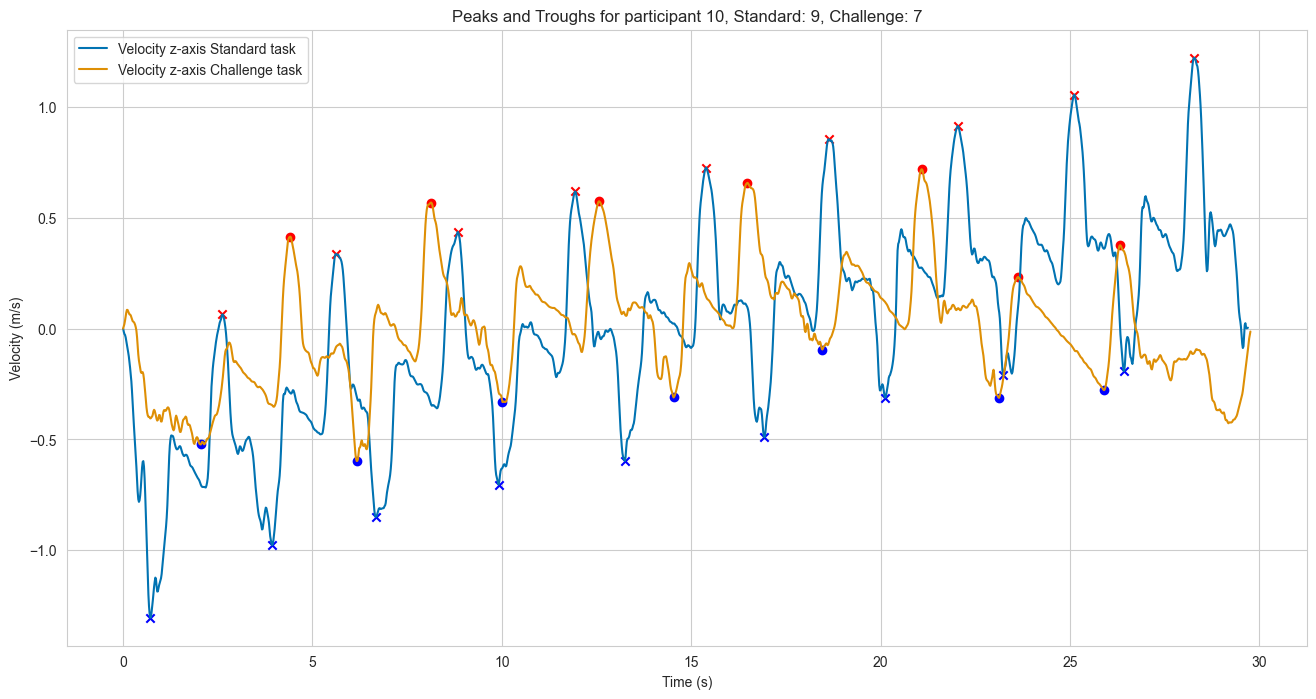

In [ ]:
# For each participant in dfs_stand, calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y
counts_standard = []
counts_challenge = []

for i in range(len(dfs_sit_to_stand_no_preprocessed)):
    import matplotlib.pyplot as plt
    # Plot the peaks and troughs of the velocity_z, velocity_x and velocity_y

    dataframe_standard = dfs_sit_to_stand_no_preprocessed[i]
    dataframe_challenge = dfs_sit_to_stand_yes_preprocessed[i]


    plt.figure(figsize=(16, 8))
    # Calculate the peaks and troughs of the velocity_z, velocity_x and velocity_y respectively
    standard_peaks_z, standard_troughs_z = calculate_peaks_and_troughs(dataframe_standard, 'velocity_z')
    challenge_peaks_z, challenge_troughs_z = calculate_peaks_and_troughs(dataframe_challenge, 'velocity_z')

    count_standard = (len(standard_peaks_z) + len(standard_troughs_z))//2
    count_challenge = (len(challenge_peaks_z) + len(challenge_troughs_z))//2

    counts_standard.append(count_standard)
    counts_challenge.append(count_challenge)

    plt.plot(dataframe_standard['time_s'], dataframe_standard['velocity_z'], label='Velocity z-axis Standard task',)
    plt.scatter(dataframe_standard['time_s'][standard_peaks_z], dataframe_standard['velocity_z'][standard_peaks_z], color='red', marker='x')
    plt.scatter(dataframe_standard['time_s'][standard_troughs_z], dataframe_standard['velocity_z'][standard_troughs_z], color='blue', marker='x')

    plt.plot(dataframe_challenge['time_s'], dataframe_challenge['velocity_z'], label='Velocity z-axis Challenge task')
    plt.scatter(dataframe_challenge['time_s'][challenge_peaks_z], dataframe_challenge['velocity_z'][challenge_peaks_z], color='red', marker='o')
    plt.scatter(dataframe_challenge['time_s'][challenge_troughs_z], dataframe_challenge['velocity_z'][challenge_troughs_z], color='blue', marker='o')

    debug = False
    if debug:
        # Plot a straight line with x=0 at every trough of standard task
        for trough in standard_troughs_z:
            plt.axvline(x=dataframe_standard['time_s'][trough], color='black', linestyle='--')

        for trough in challenge_troughs_z:
            plt.axvline(x=dataframe_challenge['time_s'][trough], color='green', linestyle='--')
    

    plt.legend()
    plt.title(f'Peaks and Troughs for participant {i+1}, Standard: {count_standard}, Challenge: {count_challenge}')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.show()
    
    




In [16]:
counts_standard, counts_challenge 

(array([ 9,  8,  5, 11,  8,  8,  8,  8,  6,  9]),
 array([4, 8, 5, 6, 6, 7, 6, 8, 7, 7]))

In [15]:
import numpy as np


counts_standard = np.array(counts_standard)
counts_challenge = np.array(counts_challenge)

print(counts_standard)
print(counts_challenge)

[ 9  8  5 11  8  8  8  8  6  9]
[4 8 5 6 6 7 6 8 7 7]


In [17]:
print(counts_standard - counts_challenge)

[ 5  0  0  5  2  1  2  0 -1  2]


NameError: name 'sns' is not defined

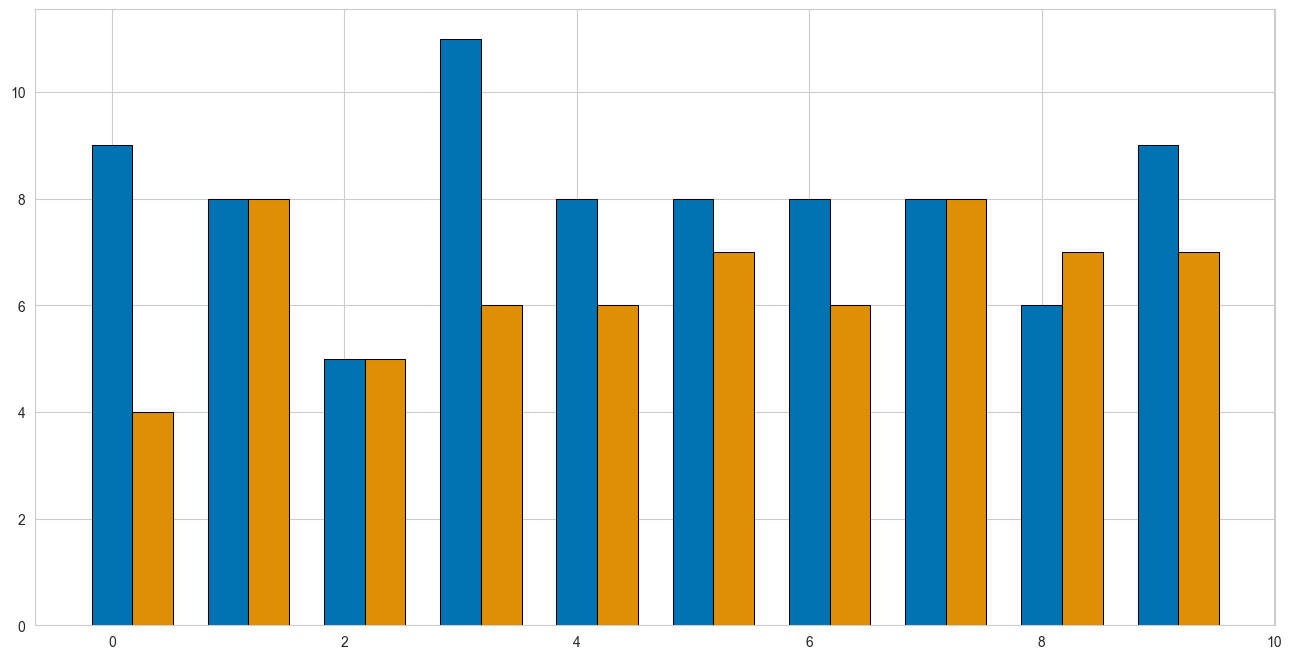

In [ ]:
ind = np.arange(len(counts_standard))
width = 0.35

plt.figure(figsize=(16, 8))
plt.bar(ind, counts_standard, width, label='Standard',  edgecolor='black', linewidth=0.75,)
plt.bar(ind + width, counts_challenge, width, label='Challenge',  edgecolor='black', linewidth=0.75,)
sns.set_palette('colorblind')
sns.set_style('whitegrid')
# Labels and title
plt.ylabel('No. of Sit-to-Stand Cycles')
plt.xlabel('Participant')
# plt.title('Comparison of Number of Standard vs Challenge Counts')
plt.xticks(ind + width / 2, [f'P{i+1}' for i in range(len(counts_standard))])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(np.arange(0, 13, 1))
plt.show()

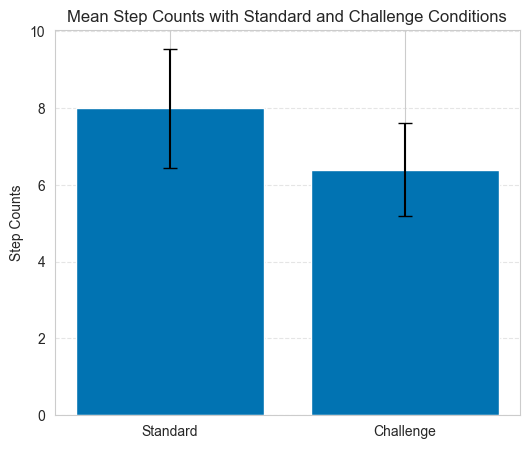

In [147]:
# Plot the mean of the sit to stand cycles for each participant

In [136]:
import numpy as np
import pandas as pd
# Create DataFrame
df = pd.DataFrame({
    'Participant': [f'P{i+1}' for i in range(len(counts_standard))],
    'No. Of Sit-to-Stand Cycles': counts_standard,
    'No. Of Sit-to-Stand Cycles with Cognitive Load': counts_challenge
})

# Display table
df
df.to_csv('sit_to_stand_cycles.csv')

In [99]:
# print length of all the dataframes in dfs_sit_to_stand_no_preprocessed and dfs_sit_to_stand_yes_preprocessed
for i in range(len(dfs_sit_to_stand_no_preprocessed)):
    print(len(dfs_sit_to_stand_no_preprocessed[i]), len(dfs_sit_to_stand_yes_preprocessed[i]))
    

1787 1787
1789 1787
1783 1785
1791 1787
3586 3596
1788 1783
1785 1787
3575 3583
3569 3575
1783 1787


# Normality tests


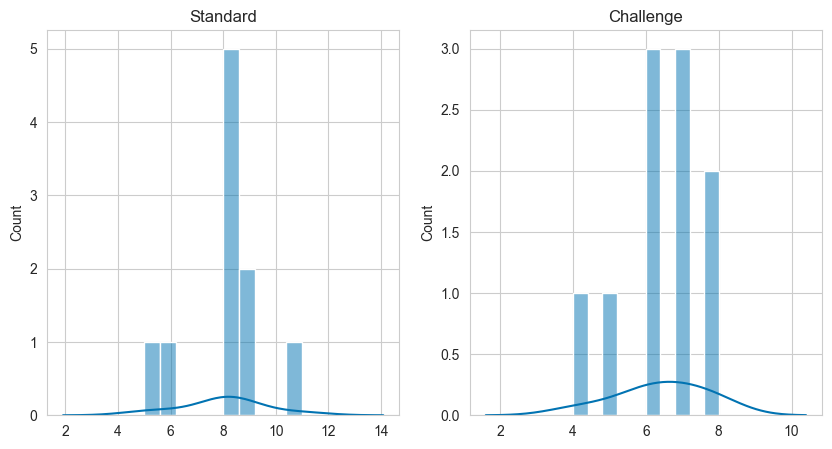

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of counts_standard and counts_challenge with a fit line
# Plot subplots of counts_standard and counts_challenge
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(counts_standard, bins=10, alpha=0.5, label='Standard', ax=axs[0])
sns.histplot(counts_challenge, bins=10, alpha=0.5, label='Challenge', ax=axs[1])
# Add a fit line
sns.kdeplot(counts_standard, label='Standard', ax=axs[0])
sns.kdeplot(counts_challenge, label='Challenge', ax=axs[1])
axs[0].set_title('Standard')
axs[1].set_title('Challenge')
plt.show()


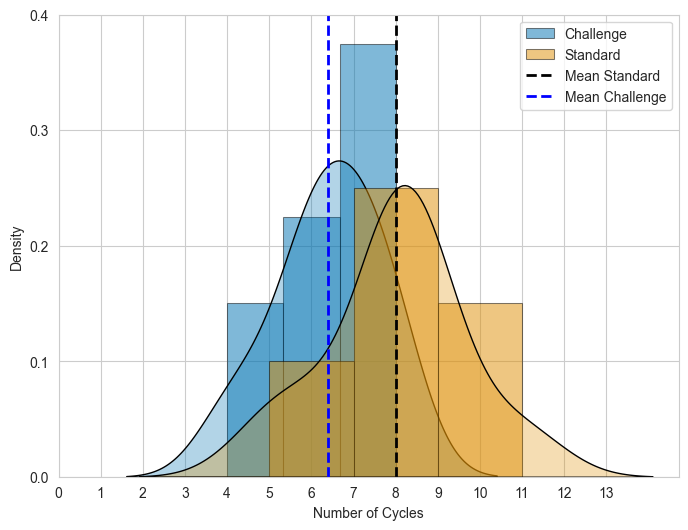

In [ ]:
plt.figure(figsize=(8, 6))
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('colorblind')
cb_colors = sns.color_palette("colorblind", as_cmap=True)
plt.hist(counts_challenge, bins=3, label='Challenge', edgecolor='black', linewidth=0.75, density=True, alpha=0.5)
sns.kdeplot(counts_challenge, fill=True, alpha=0.3, edgecolor='black', color=cb_colors[0])

# add border to the plot
plt.hist(counts_standard, bins=3, label='Standard', edgecolor='black', linewidth=0.75, density=True, alpha=0.5)
sns.kdeplot(counts_standard, fill=True, alpha=0.3, edgecolor='black', color=cb_colors[1])

# Plot the mean of the counts_standard and counts_challenge as a vertical line
plt.axvline(x=np.mean(counts_standard),  label='Mean Standard', color='black', linestyle='--', linewidth=2)
plt.axvline(x=np.mean(counts_challenge), label='Mean Challenge', color='blue', linestyle='--', linewidth=2)

# Plot a fit line

# plt.title('Distribution of Cycles for Standard and Challenge Sit to Stand tasks')

plt.xlabel('Number of Cycles')
plt.xticks(np.arange(0, 14., 1))
plt.yticks(np.arange(0, 0.5, 0.1))
plt.ylabel('Density')
plt.legend()

plt.show()

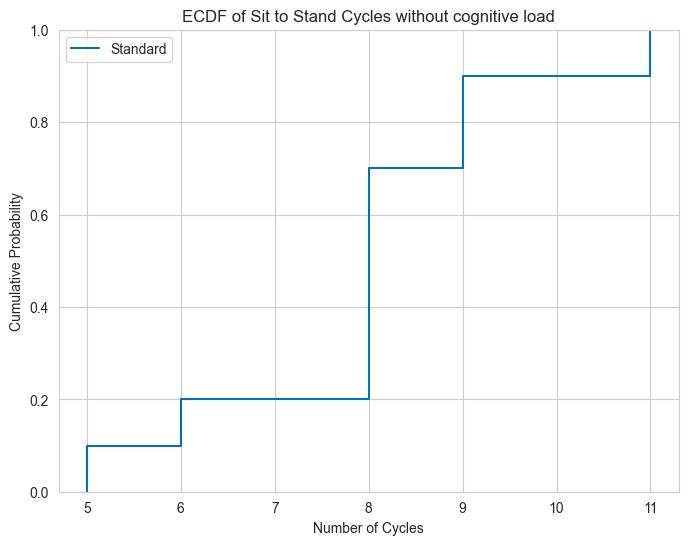

In [65]:
# Plot empirical cumulative distribution function (ECDF) for counts
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=counts_standard, label='Standard')
plt.title('ECDF of Sit to Stand Cycles without cognitive load')
plt.xlabel('Number of Cycles')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

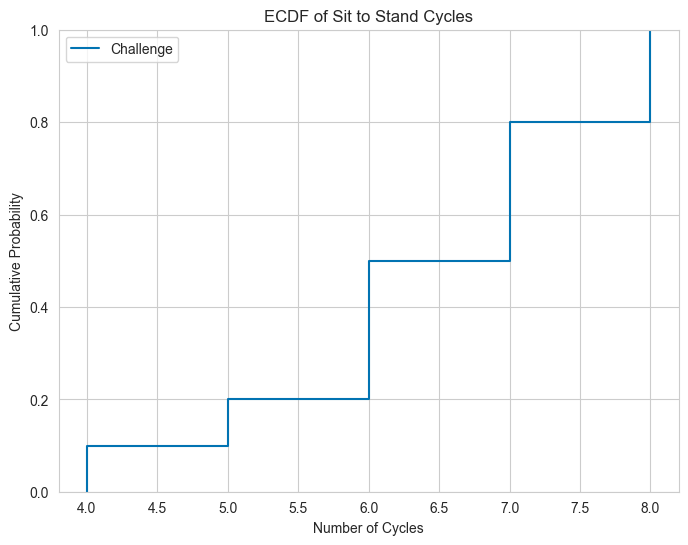

In [66]:
# Plot empirical cumulative distribution function (ECDF) for counts
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=counts_challenge, label='Challenge')
plt.title('ECDF of Sit to Stand Cycles')
plt.xlabel('Number of Cycles')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

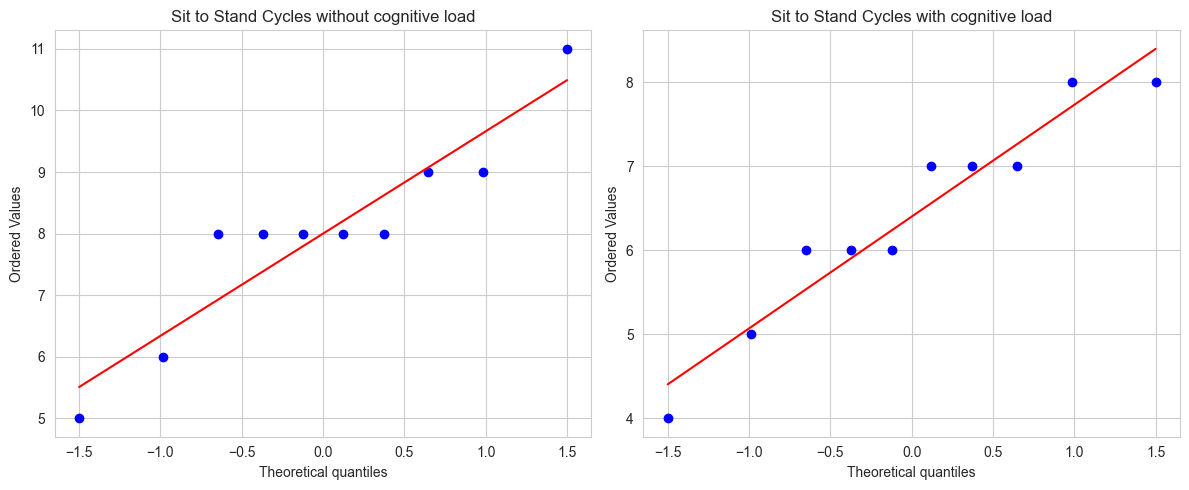

In [67]:
# Create Q-Q plots to assess normality
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for standard condition
stats.probplot(counts_standard, dist="norm", plot=ax1)
ax1.set_title("Sit to Stand Cycles without cognitive load")

# Q-Q plot for challenge condition  
stats.probplot(counts_challenge, dist="norm", plot=ax2, )
ax2.set_title("Sit to Stand Cycles with cognitive load")

plt.tight_layout()
plt.show()


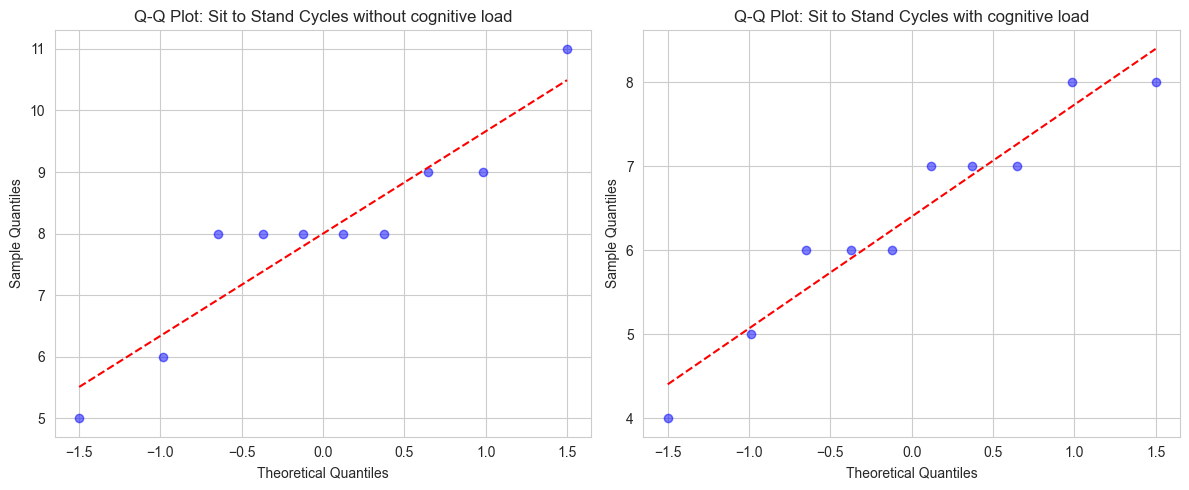

In [68]:
# Create Q-Q plots using seaborn
import seaborn as sns
import numpy as np

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for standard condition
probplot_data = stats.probplot(counts_standard)
ax1.scatter(probplot_data[0][0], probplot_data[0][1], color='blue', alpha=0.5)
ax1.plot(probplot_data[0][0], probplot_data[1][0] * probplot_data[0][0] + probplot_data[1][1], color='red', linestyle='--')
ax1.set_title("Q-Q Plot: Sit to Stand Cycles without cognitive load")
ax1.set_xlabel("Theoretical Quantiles")
ax1.set_ylabel("Sample Quantiles")

# Q-Q plot for challenge condition
probplot_data = stats.probplot(counts_challenge)
ax2.scatter(probplot_data[0][0], probplot_data[0][1], color='blue', alpha=0.5)
ax2.plot(probplot_data[0][0], probplot_data[1][0] * probplot_data[0][0] + probplot_data[1][1], color='red', linestyle='--')
ax2.set_title("Q-Q Plot: Sit to Stand Cycles with cognitive load")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()


In [69]:
from scipy.stats import shapiro

counts_standard 
stat, p = shapiro(counts_standard)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns


Shapiro-Wilk test: p-value = 0.2106
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


<Axes: ylabel='Count'>

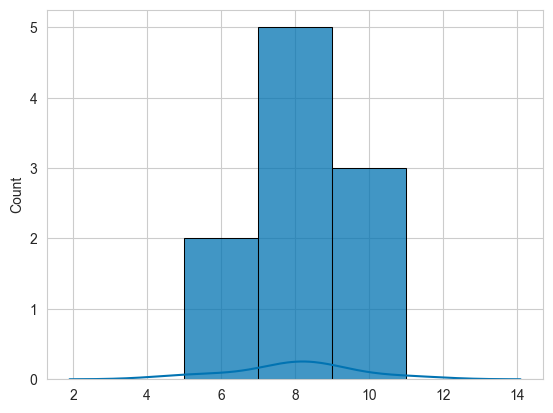

In [70]:
# add border to the plot
sns.histplot(counts_standard, bins=3, label='Standard', edgecolor='black', linewidth=0.75)
sns.kdeplot(counts_standard)

Shapiro-Wilk test: p-value = 0.4453
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


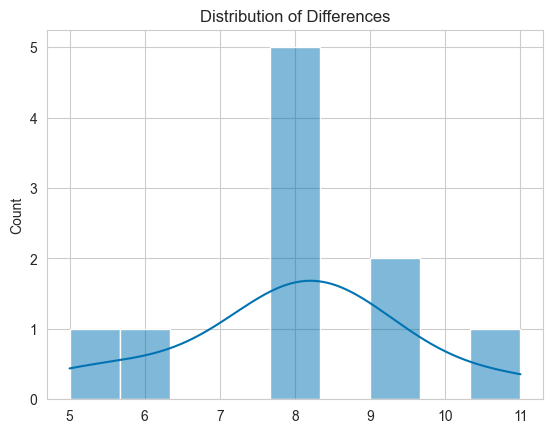

In [71]:
from scipy.stats import shapiro

stat, p = shapiro(counts_challenge)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(counts_standard, kde=True)
plt.title("Distribution of Differences")
plt.show()


Shapiro-Wilk test: p-value = 0.1189
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


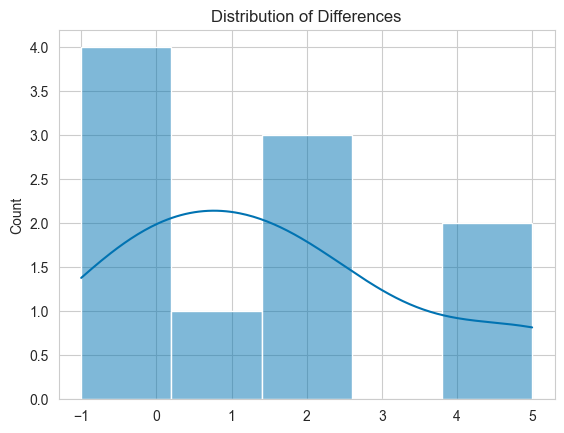

In [72]:
from scipy.stats import shapiro

diff = counts_standard - counts_challenge
stat, p = shapiro(diff)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(diff, kde=True)
plt.title("Distribution of Differences")
plt.show()


In [73]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(counts_standard, counts_challenge)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")

Paired t-test: t = 2.449, p = 0.0368
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.


In [140]:
from scipy.stats import ttest_rel

# Two-sided t-test
t_stat, p_val_two_sided = ttest_rel(counts_challenge, counts_standard)

# Mean difference
mean_diff = np.mean(counts_challenge - counts_standard)

# One-sided p-value (H₁: Challenge < Standard)
if mean_diff < 0:
    p_val_one_sided = p_val_two_sided / 2
else:
    p_val_one_sided = 1 - (p_val_two_sided / 2)

# Results
print(f"t = {t_stat:.3f}, one-sided p = {p_val_one_sided:.4f}")

# Conclusion
if p_val_one_sided < 0.05:
    print("Reject H₀: Significant decrease in count with challenge.")
else:
    print("Fail to reject H₀: No significant decrease observed.")

t = -2.449, one-sided p = 0.0184
Reject H₀: Significant decrease in count with challenge.


In [148]:
#Print mean of counts_standard and counts_challenge
print(np.mean(counts_standard))
print(np.mean(counts_challenge))

#Print standard deviation of counts_standard and counts_challenge
print(np.std(counts_standard))
print(np.std(counts_challenge))

#Print variance of counts_standard and counts_challenge
print(np.var(counts_standard))
print(np.var(counts_challenge))

8.0
6.4
1.5491933384829668
1.2
2.4
1.44


In [74]:
# Get arrays for means of acceleration magnitude for each task

means_yes = [df['acceleration_magnitude'].mean() for df in dfs_sit_to_stand_yes_preprocessed]
means_no = [df['acceleration_magnitude'].mean() for df in dfs_sit_to_stand_no_preprocessed]

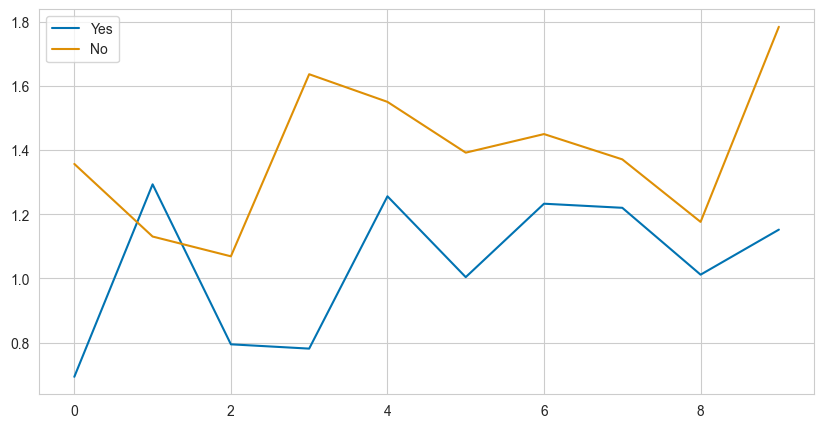

In [75]:
# Plot the means of the acceleration magnitude for each task

plt.figure(figsize=(10, 5))
plt.plot(means_yes, label='Yes')
plt.plot(means_no, label='No')
plt.legend()
plt.show()

In [76]:
means_yes

[np.float64(0.6932785640948899),
 np.float64(1.2934919941263634),
 np.float64(0.794523460240175),
 np.float64(0.7811174815974915),
 np.float64(1.256181217106662),
 np.float64(1.0040705073076044),
 np.float64(1.2330480911660822),
 np.float64(1.2202952465532528),
 np.float64(1.0117355099504877),
 np.float64(1.1522011601310023)]

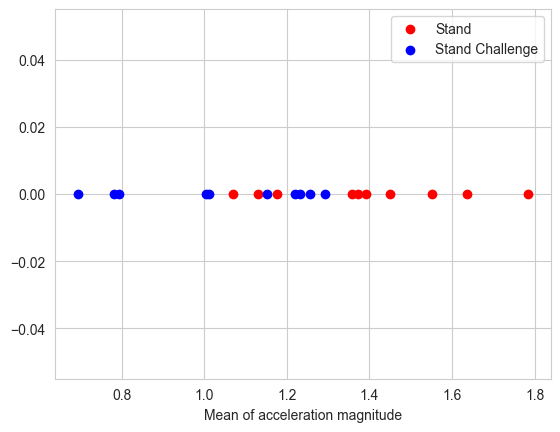

In [77]:
# Plot the means of acceleration magnitude for each subject

means_stand = means_no
means_stand_challenge = means_yes

import matplotlib.pyplot as plt
plt.scatter(means_stand, np.zeros_like(means_stand), c='red', label='Stand')
plt.scatter(means_stand_challenge, np.zeros_like(means_stand_challenge), c='blue', label='Stand Challenge')
plt.legend()
plt.xlabel('Mean of acceleration magnitude')
plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Example Data: Replace with your real mean magnitude and optional second feature
# If you have only mean magnitude, you can still run k-means, but boundary plots need 2D
np.random.seed(42)
mean_magnitude_no_load = means_stand
mean_magnitude_load = means_stand_challenge

counts_standard_array = np.array(counts_standard)
counts_challenge_array = np.array(counts_challenge)
# Combine features
X = np.column_stack((
    np.concatenate([means_stand, means_stand_challenge]),
    np.concatenate([counts_standard_array, counts_challenge_array])
    )).reshape(-1, 1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X


In [79]:
# K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
centroids, labels

(array([[1.35044644],
        [7.36842105]]),
 array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1], dtype=int32))

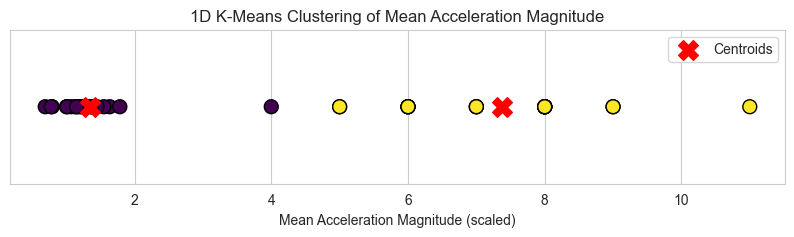

In [80]:
# Visualize the clusters

plt.figure(figsize=(10, 2))
plt.scatter(X_scaled, np.zeros_like(X_scaled), c=labels, s=100, cmap='viridis', edgecolor='k')
plt.scatter(centroids, [0]*len(centroids), c='red', s=200, marker='X', label='Centroids')
plt.title('1D K-Means Clustering of Mean Acceleration Magnitude')
plt.xlabel('Mean Acceleration Magnitude (scaled)')
plt.yticks([])
plt.legend()
plt.show()

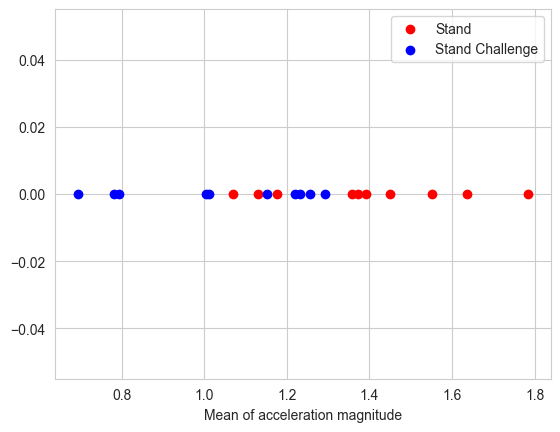

In [81]:
# Plot the means of acceleration magnitude for each subject

means_stand = means_no
means_stand_challenge = means_yes

import matplotlib.pyplot as plt
plt.scatter(means_stand, np.zeros_like(means_stand), c='red', label='Stand')
plt.scatter(means_stand_challenge, np.zeros_like(means_stand_challenge), c='blue', label='Stand Challenge')
plt.legend()
plt.xlabel('Mean of acceleration magnitude')
plt.show()

In [82]:
counts_standard, counts_challenge

(array([ 9,  8,  5, 11,  8,  8,  8,  8,  6,  9]),
 array([4, 8, 5, 6, 6, 7, 6, 8, 7, 7]))

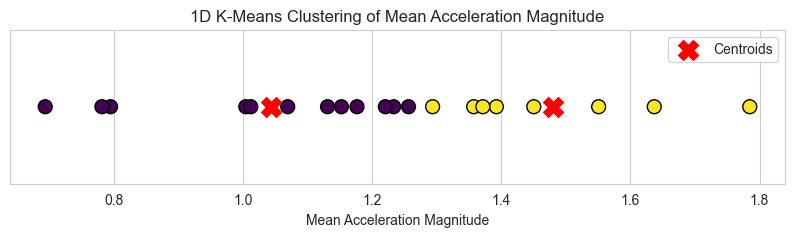

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Example Data: Replace with your real mean magnitude and optional second feature
# If you have only mean magnitude, you can still run k-means, but boundary plots need 2D
np.random.seed(42)
mean_magnitude_no_load = means_stand
mean_magnitude_load = means_stand_challenge

# Combine features
X = np.concatenate([means_stand, means_stand_challenge]).reshape(-1, 1)

# Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
X_scaled = X


# K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=40)
kmeans.fit(X_scaled)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
centroids, labels

# Visualize the clusters
plt.figure(figsize=(10, 2))
plt.scatter(X_scaled, np.zeros_like(X_scaled), c=labels, s=100, cmap='viridis', edgecolor='k')
plt.scatter(centroids, [0]*len(centroids), c='red', s=200, marker='X', label='Centroids')
plt.title('1D K-Means Clustering of Mean Acceleration Magnitude')
plt.xlabel('Mean Acceleration Magnitude')
plt.yticks([])
plt.legend()
plt.show()

In [84]:
X

array([[1.35709055],
       [1.13069752],
       [1.06896533],
       [1.63689184],
       [1.55070724],
       [1.39231585],
       [1.45023621],
       [1.37132292],
       [1.1763166 ],
       [1.78488787],
       [0.69327856],
       [1.29349199],
       [0.79452346],
       [0.78111748],
       [1.25618122],
       [1.00407051],
       [1.23304809],
       [1.22029525],
       [1.01173551],
       [1.15220116]])

In [85]:
# Calculate the standard deviation of acceleration magnitude for each participant

# Calculate the standard deviation of acceleration magnitude for each participant
standard_deviation_standard = []
standard_deviation_cognitive = []
for i, dframe in enumerate(dfs_sit_to_stand_no):
    standard_deviation_standard.append(np.std(dframe['acceleration_magnitude']))
for i, dframe in enumerate(dfs_sit_to_stand_yes):
    standard_deviation_cognitive.append(np.std(dframe['acceleration_magnitude']))

print(standard_deviation_standard)
print(standard_deviation_cognitive)

[np.float64(0.8700855127257366), np.float64(0.6881307413010024), np.float64(0.9626394591012096), np.float64(0.9062812475881615), np.float64(0.9243580811763972), np.float64(1.1715986012078183), np.float64(0.9576024634005662), np.float64(0.810525266381103), np.float64(0.777237973901715), np.float64(1.1555174984404122)]
[np.float64(0.6106690394251929), np.float64(0.7929886101681796), np.float64(0.6606759889038925), np.float64(0.5861735460152298), np.float64(0.8409373821410688), np.float64(0.7159018259494485), np.float64(0.9235200910137639), np.float64(0.7481220619867645), np.float64(0.5925078268252462), np.float64(0.7462317051623197)]


In [86]:
# Calculate the mean acceleration along z axis for each participant
mean_acceleration_z_standard = []
mean_acceleration_z_cognitive = []
for i, dframe in enumerate(dfs_sit_to_stand_no):
    mean_acceleration_z_standard.append(np.mean(dframe['freeAcceleration_m/s²_z']))
for i, dframe in enumerate(dfs_sit_to_stand_yes):
    mean_acceleration_z_cognitive.append(np.mean(dframe['freeAcceleration_m/s²_z']))

print(mean_acceleration_z_standard)
print(mean_acceleration_z_cognitive)

[np.float64(0.08467820219898711), np.float64(-0.15520669791182226), np.float64(0.1213451241975547), np.float64(0.12385896278062535), np.float64(-0.1397466745824445), np.float64(0.24884597176207493), np.float64(0.0465574530742297), np.float64(-0.20408207379205595), np.float64(-0.20932464669082093), np.float64(-0.27991888083962985)]
[np.float64(0.13237928955571462), np.float64(-0.11703832490709008), np.float64(0.08270781302244258), np.float64(0.11733988858704533), np.float64(-0.16280980057915462), np.float64(0.2797845691673023), np.float64(0.24212110089501707), np.float64(-0.19456409795953108), np.float64(-0.1239400418579021), np.float64(-0.21841451799507552)]


In [87]:
dfs_sit_to_stand_no[0]

,timestamp_ms,timestamp_μs,freeAcceleration_m/s²_x,freeAcceleration_m/s²_y,freeAcceleration_m/s²_z,time_s,acceleration_magnitude,acc_detrended_x,acc_detrended_y,acc_detrended_z,acceleration_magnitude_detrended,velocity_z,velocity_x,velocity_y,velocity_magnitude,position_z,position_x,position_y
0,1746704814859,209719360,0.047203,-0.167005,0.283479,0.000,0.332384,-0.013365,-0.239460,0.163328,0.290165,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1746704814876,209736027,0.038527,-0.128904,0.256366,0.017,0.289524,-0.022086,-0.201454,0.136254,0.244206,0.002546,-0.000301,-0.003748,0.004541,0.000022,-0.000003,-0.000032
2,1746704814892,209752694,0.040116,-0.065615,0.185970,0.033,0.201245,-0.020543,-0.138260,0.065899,0.154533,0.004164,-0.000642,-0.006465,0.007717,0.000075,-0.000010,-0.000114
3,1746704814909,209769361,0.015788,0.011174,0.267086,0.050,0.267786,-0.044915,-0.061567,0.147054,0.165628,0.005974,-0.001199,-0.008164,0.010187,0.000161,-0.000026,-0.000238
4,1746704814926,209786028,0.013383,0.116792,0.386025,0.067,0.403528,-0.047365,0.043955,0.266033,0.273768,0.009485,-0.001983,-0.008314,0.012768,0.000293,-0.000053,-0.000378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1782,1746704844560,239419954,1.038621,-0.952962,-1.862821,29.701,2.336016,0.897970,-1.195588,-1.912185,2.427392,0.001922,-0.072213,0.069659,0.100353,0.016065,0.023060,-0.072925
1783,1746704844576,239436621,1.016820,-0.380841,-0.648541,29.717,1.264740,0.876123,-0.623562,-0.697866,1.281967,-0.018958,-0.058020,0.055105,0.082234,0.015928,0.022018,-0.071927
1784,1746704844593,239453288,1.064942,-0.680544,-0.057891,29.734,1.265145,0.924200,-0.923361,-0.107176,1.310812,-0.025801,-0.042717,0.041957,0.065198,0.015548,0.021162,-0.071102
1785,1746704844610,239469955,1.247072,-0.734097,0.777641,29.751,1.642807,1.106286,-0.977010,0.728396,1.645897,-0.020521,-0.025458,0.025803,0.041654,0.015154,0.020582,-0.070526


Cluster Centers (scaled space):
[[1.01714379 5.9        0.74164948]
 [1.41879372 8.5        0.90252101]]
Cluster Labels:
[1 1 0 1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0]


ValueError: 'colorblind' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'civid

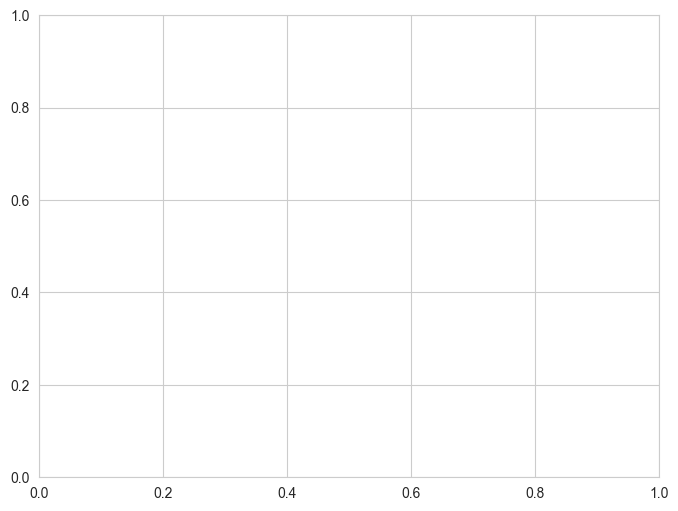

In [88]:
# New approach K means
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Example Data
np.random.seed(42)
mean_magnitude_no_load = means_stand
mean_magnitude_load = means_stand_challenge

counts_standard_array = np.array(counts_standard)
counts_challenge_array = np.array(counts_challenge)

# Combine features correctly as a 2D matrix: (20 samples, 2 features)
X = np.column_stack((
    np.concatenate([mean_magnitude_no_load, mean_magnitude_load]),
    np.concatenate([counts_standard_array, counts_challenge_array]),
    np.concatenate([standard_deviation_standard, standard_deviation_cognitive])
))

# Standardize features to bring them to similar scales
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
X_scaled = X

# K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Print results
print(f'Cluster Centers (scaled space):\n{centroids}')
print(f'Cluster Labels:\n{labels}')

# Visualize clusters
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='colorblind', s=100, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering of Sit-to-Stand Features')
plt.xlabel('Mean Acceleration Magnitude (scaled)')
plt.ylabel('Cycle Count (scaled)')
plt.legend()
plt.grid(True)
plt.show()

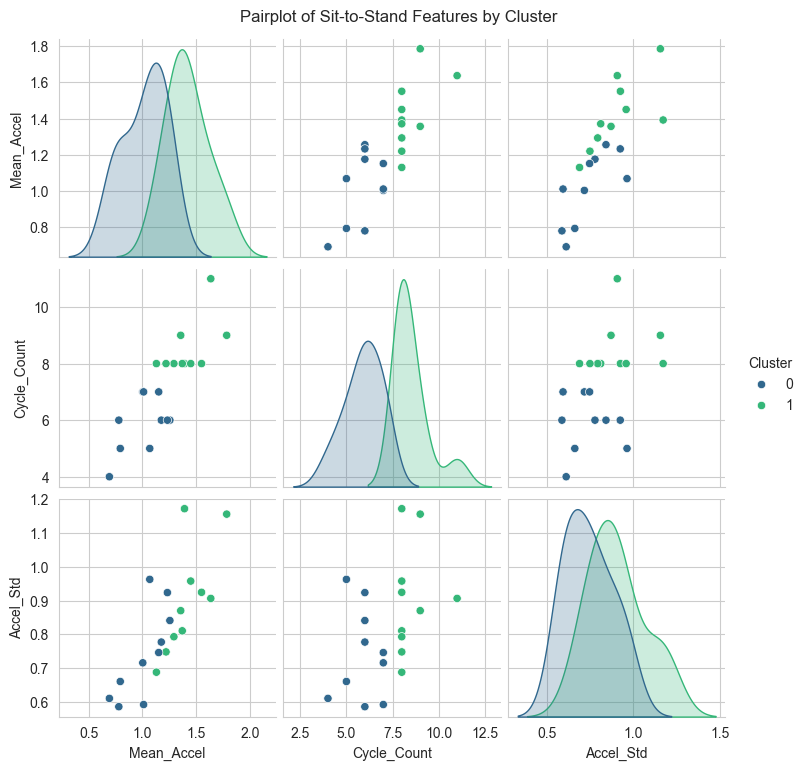

In [ ]:
import seaborn as sns
import pandas as pd

# Build a DataFrame for Seaborn
df_plot = pd.DataFrame(X_scaled, columns=['Mean_Accel', 'Cycle_Count', 'Accel_Std'])
df_plot['Cluster'] = labels

# Pairplot with hue by cluster label
sns.pairplot(df_plot, hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Sit-to-Stand Features by Cluster', y=1.02)
plt.show()

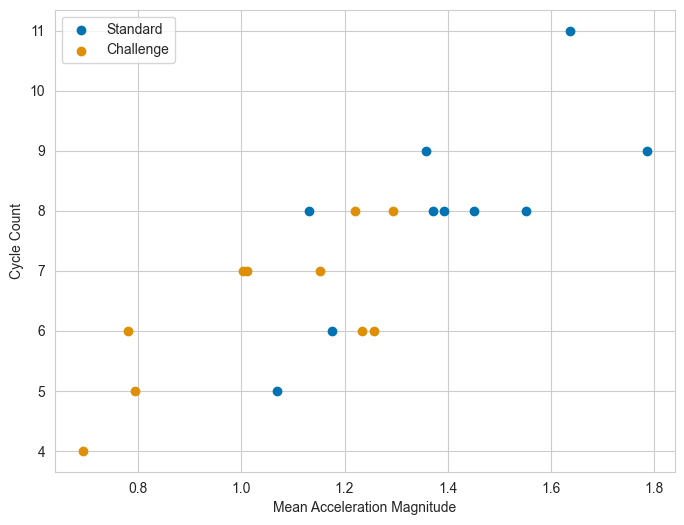

In [ ]:
# Plot Scatter plot of means magnitude and cycle count
plt.figure(figsize=(8, 6))
plt.scatter(means_stand, counts_standard, label='Standard')
plt.scatter(means_stand_challenge, counts_challenge, label='Challenge')
plt.xlabel('Mean Acceleration Magnitude')
plt.ylabel('Cycle Count')
plt.legend()
plt.show()

In [43]:
# Create ground truth labels: 0 = Standard, 1 = Challenge
true_labels = np.array([0] * len(means_stand) + [1] * len(means_stand_challenge))

# Your cluster labels
print(f'Cluster Labels: {labels}')
print(f'True Labels (0=Standard, 1=Challenge): {true_labels}')

# Simple comparison
comparison = np.column_stack((true_labels, labels))
print("\nTrue Label vs Cluster Label:\n[True, Cluster]")
print(comparison)

# Optional: calculate basic clustering accuracy
# Note: KMeans labels may be flipped (cluster 0 doesn't always map to standard, so adjust for that)
from sklearn.metrics import accuracy_score

# Try both possible mappings
acc1 = accuracy_score(true_labels, labels)
acc2 = accuracy_score(true_labels, 1 - labels)  # flipped mapping

print(f"Clustering Accuracy (mapping 1): {acc1:.2f}")
print(f"Clustering Accuracy (mapping 2 - flipped): {acc2:.2f}")

best_acc = max(acc1, acc2)
print(f"Best Clustering Accuracy: {best_acc:.2f}")

Cluster Labels: [1 1 0 1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0]
True Labels (0=Standard, 1=Challenge): [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

True Label vs Cluster Label:
[True, Cluster]
[[0 1]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]]
Clustering Accuracy (mapping 1): 0.20
Clustering Accuracy (mapping 2 - flipped): 0.80
Best Clustering Accuracy: 0.80


In [ ]:
# Correlation matrix of X_scaled
import seaborn as sns
import pandas as pd

# Create a DataFrame from X_scaled
df_X_scaled = pd.DataFrame(X_scaled, columns=['Mean_Accel', 'Cycle_Count', 'Accel_Std', 'Accel_Z'])

# Calculate the correlation matrix
corr_matrix = df_X_scaled.corr()

# Plot the correlation matrix using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

ValueError: Shape of passed values is (20, 3), indices imply (20, 4)

In [129]:
X_scaled

array([[ 0.50600937,  1.125     ,  0.29640564,  0.57352446],
       [-0.31742017,  0.5       , -0.8271802 , -0.78933282],
       [-0.54195054, -1.375     ,  0.86793395,  0.78184012],
       [ 1.52369374,  2.375     ,  0.51991731,  0.79612199],
       [ 1.21022585,  0.5       ,  0.63154326, -0.70149984],
       [ 0.63412972,  0.5       ,  2.15827401,  1.50621027],
       [ 0.84479579,  0.5       ,  0.83683008,  0.35694918],
       [ 0.55777488,  0.5       , -0.07138384, -1.06700833],
       [-0.15149592, -0.75      , -0.27693563, -1.09679294],
       [ 2.06198021,  1.125     ,  2.05897187, -1.49785973],
       [-1.90838653, -2.        , -1.30551265,  0.84452849],
       [ 0.27469072,  0.5       , -0.17967415, -0.57248697],
       [-1.5401418 , -1.375     , -0.99671558,  0.5623301 ],
       [-1.5889016 , -0.75      , -1.45677435,  0.75908519],
       [ 0.13898515, -0.75      ,  0.11641351, -0.8325283 ],
       [-0.77798393, -0.125     , -0.65569144,  1.68198162],
       [ 0.05484607, -0.

In [158]:
# Calculate the mean of velocity for each participant
mean_velocity_standard = [np.mean(dfs_sit_to_stand_no_preprocessed[i]['velocity_magnitude']) for i in range(len(dfs_sit_to_stand_no_preprocessed))]
mean_velocity_challenge = [np.mean(dfs_sit_to_stand_yes_preprocessed[i]['velocity_magnitude']) for i in range(len(dfs_sit_to_stand_yes_preprocessed))]

In [162]:
# Calculate array for min and max acceleration magnitude for each participant
min_acceleration_magnitude_standard = [np.min(dfs_sit_to_stand_no_preprocessed[i]['acceleration_magnitude']) for i in range(len(dfs_sit_to_stand_no_preprocessed))]
max_acceleration_magnitude_standard = [np.max(dfs_sit_to_stand_no_preprocessed[i]['acceleration_magnitude']) for i in range(len(dfs_sit_to_stand_no_preprocessed))]

min_acceleration_magnitude_challenge = [np.min(dfs_sit_to_stand_yes_preprocessed[i]['acceleration_magnitude']) for i in range(len(dfs_sit_to_stand_yes_preprocessed))]
max_acceleration_magnitude_challenge = [np.max(dfs_sit_to_stand_yes_preprocessed[i]['acceleration_magnitude']) for i in range(len(dfs_sit_to_stand_yes_preprocessed))]

# Print the min and max acceleration magnitude for each participant
print(min_acceleration_magnitude_standard)
print(max_acceleration_magnitude_standard)
print(min_acceleration_magnitude_challenge)
print(max_acceleration_magnitude_challenge)

[np.float64(0.13785584209017948), np.float64(0.027711173352794778), np.float64(0.045623551319110216), np.float64(0.10483407228897847), np.float64(0.0920867958598737), np.float64(0.0764419624244773), np.float64(0.05969074514168585), np.float64(0.060535735967566964), np.float64(0.11688081076711242), np.float64(0.06181726171323716)]
[np.float64(6.678202553577959), np.float64(5.8612681605094155), np.float64(7.198345867669589), np.float64(9.737835553495012), np.float64(6.561321528388209), np.float64(20.400945777446005), np.float64(6.282350495938164), np.float64(5.382499485363151), np.float64(8.220052690879193), np.float64(7.223431893443957)]
[np.float64(0.0813094091955637), np.float64(0.08805417859645552), np.float64(0.03943237404752461), np.float64(0.03564474139129994), np.float64(0.08587122305011181), np.float64(0.07673417956758376), np.float64(0.06137042624570451), np.float64(0.04445122782457672), np.float64(0.06639203371662646), np.float64(0.10692404813006698)]
[np.float64(4.93040933768

In [159]:
mean_velocity_standard, mean_velocity_challenge

([np.float64(0.42521395269415235),
  np.float64(0.5601943169229908),
  np.float64(0.6514142610292312),
  np.float64(0.49660312981949994),
  np.float64(0.5934634674742123),
  np.float64(0.605910245093749),
  np.float64(0.4559102885493243),
  np.float64(0.5051601823192431),
  np.float64(0.6811391170026345),
  np.float64(0.9369039152268089)],
 [np.float64(0.5030259338560105),
  np.float64(0.5255739196297425),
  np.float64(0.5445914204939614),
  np.float64(0.33885045563133837),
  np.float64(0.5145635932130835),
  np.float64(0.31570134221673196),
  np.float64(0.5308632958580535),
  np.float64(0.5205166391594241),
  np.float64(0.49398553718648947),
  np.float64(0.5392222785041292)])

In [ ]:
min_acceleration_magnitude_standard, min_acceleration_magnitude_challenge

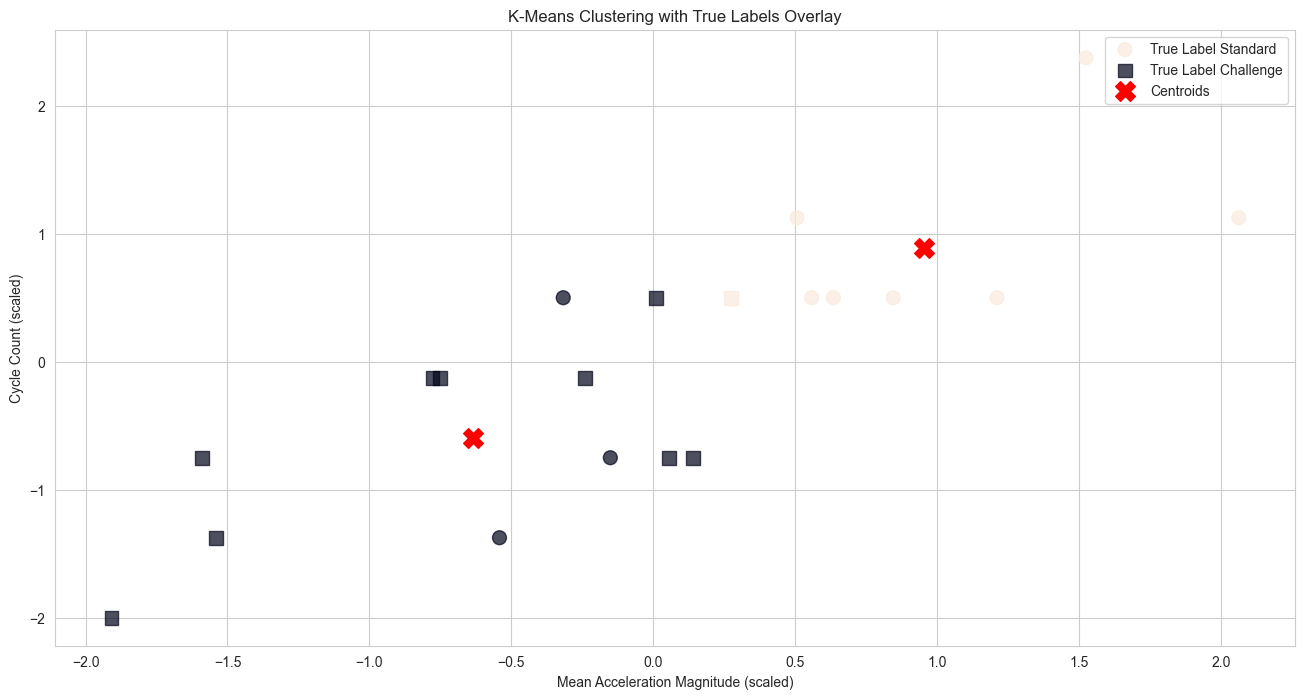

In [214]:
# New approach K means
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Example Data
np.random.seed(42)
mean_magnitude_no_load = means_stand
mean_magnitude_load = means_stand_challenge

counts_standard_array = np.array(counts_standard)
counts_challenge_array = np.array(counts_challenge)

# Combine features correctly as a 2D matrix: (20 samples, 2 features)
X = np.column_stack((
    np.concatenate([mean_magnitude_no_load, mean_magnitude_load]),
    np.concatenate([counts_standard_array, counts_challenge_array]),
    np.concatenate([standard_deviation_standard, standard_deviation_cognitive]),
    np.concatenate([mean_velocity_standard, mean_velocity_challenge]),
))

# Standardize features to bring them to similar scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_scaled = X

# K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

true_labels = np.array([0] * len(means_stand) + [1] * len(means_stand_challenge))
from sklearn.metrics import accuracy_score

plt.figure(figsize=(16, 8))
sns.set_palette('colorblind')
sns.set_style('whitegrid')

# Color by cluster, shape by true label
for true_label, marker in zip([0, 1], ['o', 's']):  # 'o' = circle, 's' = square
    idx = np.where(true_labels == true_label)
    label = "Standard" if true_label == 0 else "Challenge"
    plt.scatter(X_scaled[idx, 0], X_scaled[idx, 1], 
                c=labels[idx], 
                s=100, alpha=0.7, marker=marker, label=f'True Label {label}')

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

plt.title('K-Means Clustering with True Labels Overlay')
plt.xlabel('Mean Acceleration Magnitude (scaled)')
plt.ylabel('Cycle Count (scaled)')
plt.legend()
plt.grid(True)
plt.show()



[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)]


/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_15597/2134344175.py:59: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


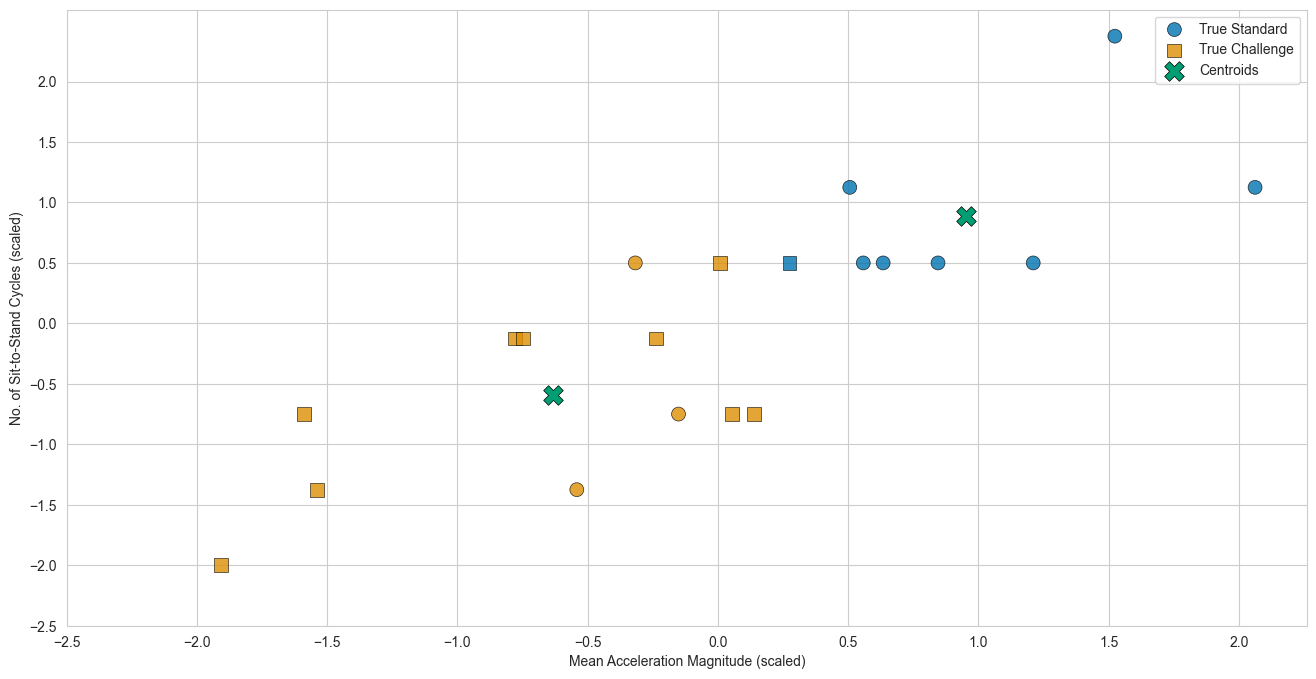

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Example Data (assuming yours are already defined)
np.random.seed(42)

# Features combined (already as in your code)
X = np.column_stack((
    np.concatenate([mean_magnitude_no_load, mean_magnitude_load]),
    np.concatenate([counts_standard_array, counts_challenge_array]),
    np.concatenate([standard_deviation_standard, standard_deviation_cognitive]),
    np.concatenate([mean_velocity_standard, mean_velocity_challenge]),
))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

true_labels = np.array([0] * len(mean_magnitude_no_load) + [1] * len(mean_magnitude_load))

# Colorblind-friendly colors (using seaborn's default colorblind palette)
cb_colors = sns.color_palette("colorblind", n_colors=3)  # At least 3 colors
print(cb_colors)
colors = []



colors.append(cb_colors[1])
colors.append(cb_colors[0])

colors.append(cb_colors[2])

plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')

# Plot by true label with shapes, color by cluster label
for true_label, marker in zip([0, 1], ['o', 's']):
    idx = np.where(true_labels == true_label)
    
    plt.scatter(
        X_scaled[idx, 0], X_scaled[idx, 1],
        c=[colors[l] for l in labels[idx]],
        marker=marker,
        s=100, alpha=0.8, linewidth=0.5, edgecolor='black',
        label=f'True {"Standard" if true_label == 0 else "Challenge"}'
    )

# Centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1], marker='X', s=200, c=cb_colors[2], label='Centroids', linewidth=0.5, edgecolor='black'
)

# plt.title('K-Means Clustering with Colorblind Palette')
plt.xlabel('Mean Acceleration Magnitude (scaled)')
plt.ylabel('No. of Sit-to-Stand Cycles (scaled)')
plt.xticks(np.arange(-2.5, 2.5, 0.5))
plt.yticks(np.arange(-2.5, 2.5, 0.5))
plt.grid(True)
plt.legend()
plt.show()

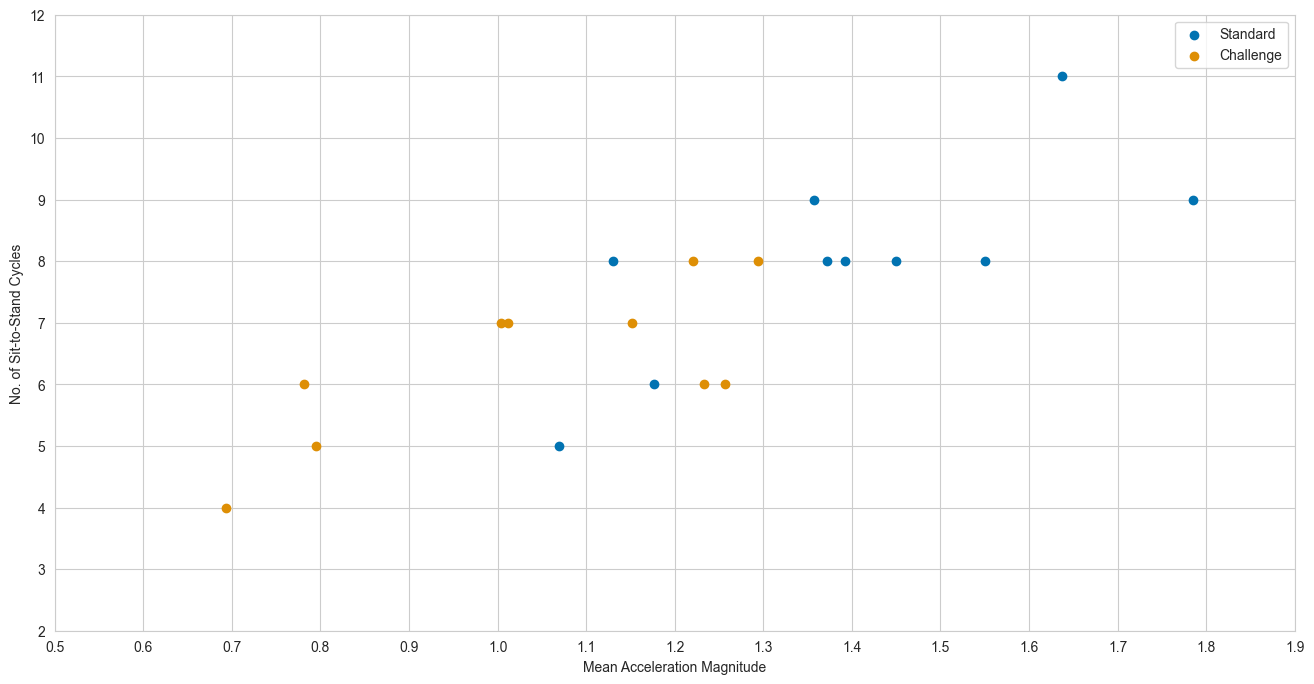

In [208]:
# Plot Scatter plot of means magnitude and cycle count
plt.figure(figsize=(16, 8))
plt.scatter(means_stand, counts_standard, label='Standard')
plt.scatter(means_stand_challenge, counts_challenge, label='Challenge')
plt.xlabel('Mean Acceleration Magnitude')
plt.ylabel('No. of Sit-to-Stand Cycles')
plt.xticks(np.arange(0.5, 2, 0.1))
plt.yticks(np.arange(2, 13, 1))
plt.legend()
plt.show()

In [183]:
# Check how many points were correctly clustered
for i in range(len(labels)):
    if labels[i] == true_labels[i]:
        print(f"Point {i} was correctly clustered")
    else:
        print(f"Point {i} was incorrectly clustered")

# Print the number of points that were correctly clustered
print(f"Number of points that were correctly clustered: {np.sum(labels == true_labels)}")

Point 0 was incorrectly clustered
Point 1 was incorrectly clustered
Point 2 was incorrectly clustered
Point 3 was correctly clustered
Point 4 was correctly clustered
Point 5 was correctly clustered
Point 6 was incorrectly clustered
Point 7 was incorrectly clustered
Point 8 was incorrectly clustered
Point 9 was correctly clustered
Point 10 was correctly clustered
Point 11 was correctly clustered
Point 12 was correctly clustered
Point 13 was correctly clustered
Point 14 was correctly clustered
Point 15 was correctly clustered
Point 16 was correctly clustered
Point 17 was correctly clustered
Point 18 was correctly clustered
Point 19 was correctly clustered
Number of points that were correctly clustered: 14
